# 머신러닝 미니 프로젝트

In [254]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import koreanize_matplotlib
from lightgbm import plot_importance
from lightgbm import LGBMClassifier
from xgboost import plot_importance
from hyperopt import fmin,tpe,Trials
from hyperopt import hp
from xgboost import XGBClassifier
from hyperopt import STATUS_OK
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix, roc_auc_score, f1_score
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor


In [255]:
df = pd.read_csv('InventoryData.csv')
df

,SKU_ID,SKU_Name,Category,ABC_Class,Supplier_ID,Supplier_Name,Warehouse_ID,Warehouse_Location,Batch_ID,Received_Date,...,SKU_Churn_Rate,Order_Frequency_per_month,Supplier_OnTime_Pct,FIFO_FEFO,Inventory_Status,Count_Variance,Audit_Date,Audit_Variance_Pct,Demand_Forecast_Accuracy_Pct,Notes
0,SKU0001,Pantry Product 13,Pantry,A,S005,PT Agro Raya,WHBDG,Bandung - Rancaekek,BATCH2679,2025-07-14,...,"2,39","5,00","70,68%",FIFO,In Stock,0,2025-06-26,"-7,14%","95,67%",NaN
1,SKU0002,Fresh Product 112,Fresh Produce,C,S004,PT Nusantara Supplier,WHDPS,Denpasar - Tabanan,BATCH4257,2025-04-08,...,"3,34","12,00","84,61%",FEFO,Low Stock,4,2025-08-12,"2,15%","86,00%",NaN
2,SKU0003,Meat Product 446,Meat,B,S001,PT Segar Makmur,WHBDG,Bandung - Rancaekek,BATCH6574,2025-03-15,...,"2,26","11,00","85,36%",FIFO,Expiring Soon,-5,2025-08-13,"6,85%","87,64%",NaN
3,SKU0004,Seafood Product 48,Seafood,A,S007,PT Bakerindo,WHJKT,Jakarta - Cengkareng,BATCH5333,2025-06-10,...,"2,72","10,00","72,81%",FIFO,Expiring Soon,0,2025-07-13,"-6,69%","71,15%",NaN
4,SKU0005,Personal Product 194,Personal Care,A,S002,PT Indo Fresh,WHDPS,Denpasar - Tabanan,BATCH6925,2025-06-26,...,"2,18","2,00","70,93%",FIFO,In Stock,-5,2025-06-11,"1,23%","76,25%",High return rate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,SKU0996,Fresh Product 377,Fresh Produce,C,S006,PT Frozen Express,WHJKT,Jakarta - Cengkareng,BATCH8871,2025-07-20,...,"2,51","8,00","79,06%",FEFO,Low Stock,2,2025-08-20,"-6,23%","80,85%",NaN
996,SKU0997,Frozen Product 125,Frozen,C,S001,PT Segar Makmur,WHDPS,Denpasar - Tabanan,BATCH9906,2025-03-16,...,"5,77","15,00","74,40%",FIFO,Low Stock,0,2025-09-04,"1,33%","88,43%",Promotional item
997,SKU0998,Fresh Product 454,Fresh Produce,C,S007,PT Bakerindo,WHBDG,Bandung - Rancaekek,BATCH1393,2025-09-09,...,"2,97","9,00","92,17%",FEFO,Low Stock,0,2025-07-22,"5,47%","91,92%",Promotional item
998,SKU0999,Meat Product 451,Meat,C,S007,PT Bakerindo,WHJKT,Jakarta - Cengkareng,BATCH2804,2025-05-07,...,"21,35","13,00","92,40%",FIFO,Low Stock,0,2025-08-04,"0,46%","93,18%",NaN


In [256]:
df['Received_Date'] = pd.to_datetime(df['Received_Date'],format='%Y-%m-%d')
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'],format='%Y-%m-%d')
df['Expiry_Date'] = pd.to_datetime(df['Expiry_Date'],format='%Y-%m-%d')
df['Audit_Date'] = pd.to_datetime(df['Audit_Date'],format='%Y-%m-%d')
df[df.select_dtypes(include='object').columns] = df.select_dtypes(include='object').apply(lambda x: x.str.replace('%',''))
df[df.select_dtypes(include='object').columns] = df.select_dtypes(include='object').apply(lambda x: x.str.replace('$',''))
df[df.select_dtypes(include='object').columns] = df.select_dtypes(include='object').apply(lambda x: x.str.replace('.',''))
df[df.select_dtypes(include='object').columns] = df.select_dtypes(include='object').apply(lambda x: x.str.replace(',','.'))
df[['Avg_Daily_Sales','Forecast_Next_30d','Days_of_Inventory','Unit_Cost_USD','Last_Purchase_Price_USD','Total_Inventory_Value_USD','SKU_Churn_Rate','Order_Frequency_per_month','Supplier_OnTime_Pct','Audit_Variance_Pct','Demand_Forecast_Accuracy_Pct']] = df[['Avg_Daily_Sales','Forecast_Next_30d','Days_of_Inventory','Unit_Cost_USD','Last_Purchase_Price_USD','Total_Inventory_Value_USD','SKU_Churn_Rate','Order_Frequency_per_month','Supplier_OnTime_Pct','Audit_Variance_Pct','Demand_Forecast_Accuracy_Pct']].astype(float)
df['Forecast_Next_30d'] = df['Forecast_Next_30d'].apply(lambda x: 1000*x if x<10 else x)

In [257]:
from datetime import datetime
df2 = df.copy()
df2 = df2[['Category','ABC_Class','Received_Date','Expiry_Date','Stock_Age_Days','Quantity_On_Hand','Damaged_Qty','Returns_Qty','Avg_Daily_Sales','Days_of_Inventory','Reorder_Point','Unit_Cost_USD','FIFO_FEFO']]
df2['Days_To_Expiry'] = (df2['Expiry_Date'] - df2['Received_Date']).dt.days
df2['Remaining_Shelf_Days'] = (df2['Expiry_Date'] - datetime.strptime('2025-09-10','%Y-%m-%d')).dt.days
df2['Days_To_Deplete'] = df2['Quantity_On_Hand']/df2['Avg_Daily_Sales']
df2['Waste_Risk'] = (df2['Days_To_Deplete']>df2['Remaining_Shelf_Days']).astype(int)
margin_days=3
df2['DTE_Tight'] = (df2['Remaining_Shelf_Days']-margin_days).clip(lower=1)
df2['Target_Tight'] = (df2['Avg_Daily_Sales']*df2['DTE_Tight']/df2['Quantity_On_Hand']).clip(upper=1.0)
df2['sell_rate'] = ((df2['Avg_Daily_Sales']*df2['Remaining_Shelf_Days']).clip(lower=1)/df2['Quantity_On_Hand']).clip(upper=1.5)
df2['damage'] = df2['Damaged_Qty']+df2['Returns_Qty']

In [258]:
df2.groupby('Category')[['Days_To_Expiry','Waste_Risk']].mean().sort_values(by='Days_To_Expiry')

,Days_To_Expiry,Waste_Risk
Category,,
Bakery,4.507246,1.000000
Seafood,7.060606,1.000000
Fresh Produce,8.472727,1.000000
Meat,12.735632,0.988506
Dairy,18.156250,0.979167
Frozen,269.813953,0.000000
Household,1091.990291,0.000000
Pantry,1100.445255,0.000000
Beverages,1100.633333,0.000000


In [259]:
df3 = df2.copy()
target = df3['Waste_Risk']
df3 = df3.drop(columns=['Days_of_Inventory','Days_To_Deplete','Damaged_Qty','Returns_Qty','Remaining_Shelf_Days','Waste_Risk','Received_Date','Expiry_Date','sell_rate','DTE_Tight','Target_Tight','damage'])
df3.select_dtypes('timedelta').astype(float)
data = pd.get_dummies(df3,columns=['Category','ABC_Class','FIFO_FEFO'],dtype=int)
X_train,X_test,y_train,y_test = train_test_split(data,target,test_size=0.2,random_state=42,stratify=target)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [260]:
# 1. 평가할 모델 리스트 정의
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss')),
    ('LightGBM', LGBMClassifier(random_state=42))
]

# 2. 성능 지표 및 분할기 설정
# 'roc_auc'는 이진 분류일 때 기본 작동하며, 다중 분류일 경우 scoring 방식을 변경해야 할 수 있습니다.
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 결과를 저장할 리스트
results_list = []

print(f"{'Model':<20} | {'Accuracy':<8} | {'Precision':<9} | {'Recall':<7} | {'F1':<6} | {'ROC-AUC':<8}")
print("-" * 80)

# 3. 반복문을 통한 모델 학습 및 평가
for name, model in models:
    # 교차 검증 수행
    cv_results = cross_validate(
        model, X_scaled, y_train, 
        cv=kf, 
        scoring=scoring, 
        return_train_score=False, 
        n_jobs=-1
    )
    
    # 각 지표의 평균값 계산
    acc = np.mean(cv_results['test_accuracy'])
    pre = np.mean(cv_results['test_precision'])
    rec = np.mean(cv_results['test_recall'])
    f1  = np.mean(cv_results['test_f1'])
    auc = np.mean(cv_results['test_roc_auc'])
    
    # 한 줄씩 출력
    print(f"{name:<20} | {acc:.4f}   | {pre:.4f}    | {rec:.4f} | {f1:.4f} | {auc:.4f}")
    
    # DataFrame 저장을 위해 딕셔너리에 추가
    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': pre,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

# 4. DataFrame 생성 및 확인
df_results = pd.DataFrame(results_list)
print("\n[최종 성능 비교 데이터프레임]")
display(df_results) # 주피터 노트북 환경인 경우

Model                | Accuracy | Precision | Recall  | F1     | ROC-AUC 
--------------------------------------------------------------------------------
Logistic Regression  | 0.9988   | 0.9973    | 1.0000 | 0.9986 | 0.9985
Decision Tree        | 0.9938   | 0.9973    | 0.9870 | 0.9920 | 0.9924
Random Forest        | 0.9988   | 0.9973    | 1.0000 | 0.9986 | 0.9997
Gradient Boosting    | 0.9950   | 0.9973    | 0.9903 | 0.9937 | 0.9940
XGBoost              | 0.9975   | 0.9946    | 1.0000 | 0.9973 | 0.9987
LightGBM             | 0.9925   | 0.9920    | 0.9903 | 0.9910 | 0.9979

[최종 성능 비교 데이터프레임]


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.99875,0.997260,1.000000,0.998621,0.998548
1,Decision Tree,0.99375,0.997260,0.987044,0.992009,0.992386
2,Random Forest,0.99875,0.997260,1.000000,0.998621,0.999653
3,Gradient Boosting,0.99500,0.997260,0.990323,0.993662,0.994025
4,XGBoost,0.99750,0.994594,1.000000,0.997278,0.998738
5,LightGBM,0.99250,0.991997,0.990323,0.990995,0.997885


트레이닝 세트 정확도: 0.99875
검증 세트 정확도:  0.9974999999999999


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

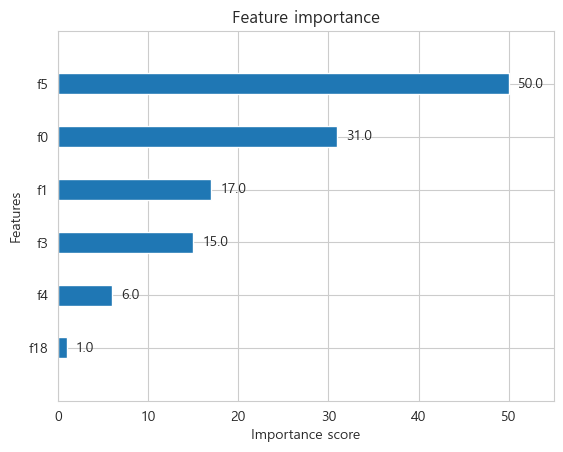

In [261]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42)
# 분할기 고정
kf = KFold(shuffle=True,random_state=42)

scores = cross_validate(xgb,X_scaled,y_train,return_train_score=True,n_jobs=-1,cv=kf)
print('트레이닝 세트 정확도:',np.mean(scores['train_score']))
print('검증 세트 정확도: ', np.mean(scores['test_score']))
gbm_score = np.mean(scores['test_score'])
xgb.fit(X_scaled,y_train)
from xgboost import plot_importance
plot_importance(xgb,max_num_features=20,height=0.4)


트레이닝 세트 정확도: 1.0
검증 세트 정확도:  0.9925


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

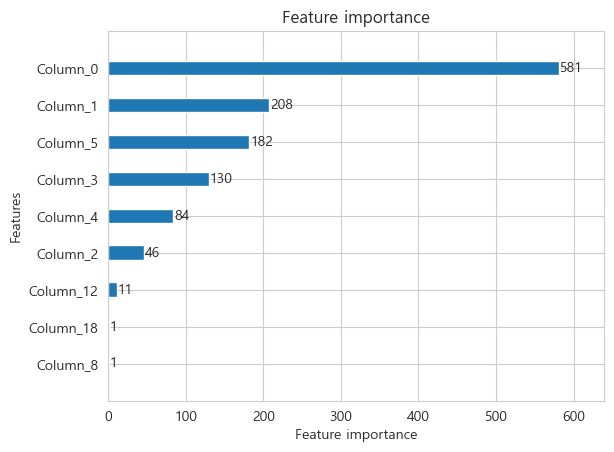

In [262]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state=42,verbose=-1)
# 분할기 고정
kf = KFold(shuffle=True,random_state=42)

scores = cross_validate(lgbm,X_scaled,y_train,return_train_score=True,n_jobs=-1,cv=kf)
print('트레이닝 세트 정확도:',np.mean(scores['train_score']))
print('검증 세트 정확도: ', np.mean(scores['test_score']))
gbm_score = np.mean(scores['test_score'])
lgbm.fit(X_scaled,y_train)
from lightgbm import plot_importance
plot_importance(lgbm,max_num_features=20,height=0.4)

In [263]:
df4 = df2.copy()
# df4 = df4[df4['Remaining_Shelf_Days']>=0]
target = df4['Target_Tight']
df4 = df4.drop(columns=['Days_of_Inventory','Days_To_Deplete','Remaining_Shelf_Days','Waste_Risk','Received_Date','Expiry_Date','sell_rate','Target_Tight','DTE_Tight','Damaged_Qty','Returns_Qty'])
df4.select_dtypes('timedelta').astype(float)
data = pd.get_dummies(df4,columns=['Category','ABC_Class','FIFO_FEFO'],dtype=int)
print(df4.info())
print(data.info())
print(target.info())
print(target.max())
print(target.min())
target[target==target.max()].count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Category          1000 non-null   object 
 1   ABC_Class         1000 non-null   object 
 2   Stock_Age_Days    1000 non-null   int64  
 3   Quantity_On_Hand  1000 non-null   int64  
 4   Avg_Daily_Sales   1000 non-null   float64
 5   Reorder_Point     1000 non-null   float64
 6   Unit_Cost_USD     1000 non-null   float64
 7   FIFO_FEFO         1000 non-null   object 
 8   Days_To_Expiry    1000 non-null   int64  
 9   damage            1000 non-null   int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 78.3+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Stock_Age_Days          1000 non-null   int64

np.int64(587)

Text(0.5, 1.0, '유통기한 내 판매 예측율')

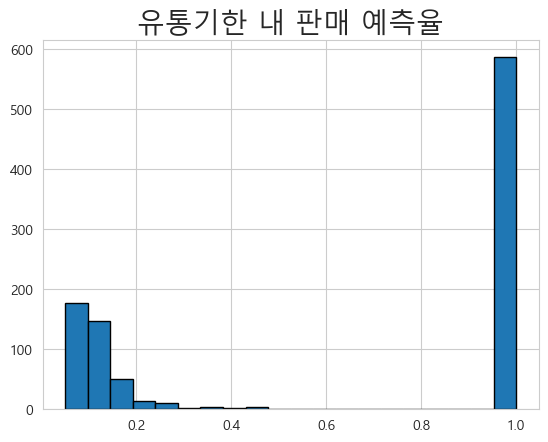

In [264]:
plt.hist(target,bins=20,edgecolor='k')
plt.title('유통기한 내 판매 예측율',size=20)

In [265]:
X_train,X_test,y_train,y_test = train_test_split(data,target,test_size=0.2,random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
data_scaled = scaler.transform(data)

In [266]:
sample_weights = np.where(y_train < 1.0, 5.0, 1.0)

# 3. 평가할 회귀 모델 리스트
models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge', Ridge(random_state=42)),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42, n_jobs=-1)),
    ('Gradient Boosting', GradientBoostingRegressor(random_state=42)),
    ('XGBoost', XGBRegressor(random_state=42, n_jobs=-1)),
    ('LightGBM', LGBMRegressor(random_state=42, n_jobs=-1,verbose=-1))
]

results_list = []

# 4. 모델별 학습 및 지표 출력
print(f"{'Model':<20} | {'R2':<8} | {'MAE':<8} | {'RMSE':<8}")
print("-" * 55)

for name, model in models:
    # 학습 (가중치 적용 가능한 모델들)
    try:
        model.fit(X_scaled, y_train, sample_weight=sample_weights)
    except TypeError:
        # 일부 선형 모델 등 가중치를 지원하지 않는 경우 일반 학습
        model.fit(X_scaled, y_train)

    # 예측 및 평가
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"{name:<20} | {r2:.4f}   | {mae:.4f}   | {rmse:.4f}")

    results_list.append({
        'Model': name,
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse
    })

# 5. 결과 저장 및 확인
df_regression_results = pd.DataFrame(results_list)

Model                | R2       | MAE      | RMSE    
-------------------------------------------------------
Linear Regression    | 0.9432   | 0.0481   | 0.1039
Ridge                | 0.9432   | 0.0482   | 0.1040
Decision Tree        | 0.9892   | 0.0141   | 0.0454
Random Forest        | 0.9919   | 0.0117   | 0.0393
Gradient Boosting    | 0.9882   | 0.0189   | 0.0473
XGBoost              | 0.9947   | 0.0108   | 0.0317
LightGBM             | 0.9844   | 0.0225   | 0.0545


c:\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [267]:
# 2. 샘플 가중치 생성 (위험 상품군에 5배 가중치)
# 판매율이 낮을수록(위험할수록) 더 중요하게 학습하도록 설정
sample_weights = np.where(y_train < 1.0, 5.0, 1.0)

# 3. 평가할 회귀 모델 리스트
models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge', Ridge(random_state=42)),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42, n_jobs=-1)),
    ('Gradient Boosting', GradientBoostingRegressor(random_state=42)),
    ('XGBoost', XGBRegressor(random_state=42, n_jobs=-1)),
    ('LightGBM', LGBMRegressor(random_state=42, n_jobs=-1))
]
kf = KFold(shuffle=True,random_state=42)
results_list = []

# 4. 모델별 학습 및 지표 출력
print(f"{'Model':<20} | {'R2':<8} | {'MAE':<8} | {'RMSE':<8}")
print("-" * 55)

for name, model in models:
    fold_r2,fold_mae,fold_rmse=[],[],[]
    for train_index,val_index in kf.split(X_scaled):
        X_tr,X_valid = X_scaled[train_index],X_scaled[val_index]
        y_tr,y_valid = y_train.iloc[train_index],y_train.iloc[val_index]
        w_t = sample_weights[train_index]
        
        try:
            model.fit(X_tr,y_tr,sample_weight=w_t)
        except:
            model.fit(X_tr,y_tr)
        
        preds = model.predict(X_valid)
        fold_r2.append(r2_score(y_valid,preds))
        fold_mae.append(mean_absolute_error(y_valid,preds))
        fold_rmse.append(np.sqrt(mean_squared_error(y_valid,preds)))
        
    print(f"{name:<20} | {np.mean(fold_r2):.4f}   | {np.mean(fold_mae):.4f}   | {np.mean(fold_rmse):.4f}")
    results_list.append({
        'Model': name,
        'R2': np.mean(fold_r2),
        'MAE': np.mean(fold_mae),
        'RMSE': np.mean(fold_rmse)
    })

# 5. 결과 저장 및 확인
df_regression_results = pd.DataFrame(results_list)

Model                | R2       | MAE      | RMSE    
-------------------------------------------------------
Linear Regression    | 0.9349   | 0.0468   | 0.1043
Ridge                | 0.9349   | 0.0468   | 0.1042
Decision Tree        | 0.9689   | 0.0167   | 0.0659
Random Forest        | 0.9790   | 0.0120   | 0.0521
Gradient Boosting    | 0.9773   | 0.0188   | 0.0574
XGBoost              | 0.9826   | 0.0111   | 0.0449


c:\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM             | 0.9635   | 0.0268   | 0.0705


c:\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [268]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sample_weights = np.where(y_train < 1.0, 5.0, 1.0)
# 1. 문제되는 파라미터(max_samples, bootstrap=False)를 제외한 안전한 그리드
param_dist = {
    'n_estimators': [100, 300, 500, 700, 1000, 1200],         # 트리 개수 확장
    'max_depth': [None, 10, 20, 30, 40, 50],                # 깊이 설정
    'min_samples_split': [2, 5, 10, 15],                    # 분할 최소 샘플 수
    'min_samples_leaf': [1, 2, 4, 8],                       # 리프 노드 최소 샘플 수
    'max_features': ['sqrt', 'log2', None, 0.7, 0.8, 0.9],  # 피처 선택 비율
}

# 2. 다중 지표 설정 (검증 단계에서 R2, MAE, RMSE를 모두 계산)
scoring_metrics = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

# 3. RandomizedSearchCV 설정
# n_iter=50으로 설정하여 다양한 조합을 시도합니다.
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=200, 
    cv=5,
    scoring=scoring_metrics,
    refit='r2', # R2가 가장 좋은 모델을 최종 모델로 선택
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# 4. 모델 학습
rf_random.fit(X_scaled, y_train, sample_weight=sample_weights)

# 5. 결과 통합 함수 (Valid와 Test 지표를 한 번에 정리)
def get_comprehensive_results(model_name, search_obj):
    best_idx = search_obj.best_index_
    best_model = search_obj.best_estimator_
    
    result = pd.DataFrame([{
        'Model': model_name,
        'Best_Params': str(search_obj.best_params_),
        # 검증(Validation) 지표
        'Valid_R2': search_obj.best_score_,
        'Valid_MAE': -search_obj.cv_results_['mean_test_mae'][best_idx],
        'Valid_RMSE': -search_obj.cv_results_['mean_test_rmse'][best_idx]
    }])
    return result

# 6. 결과 저장
df_results = get_comprehensive_results('Tuned RandomForest (Safe)', rf_random)

# 최종 확인
print(df_results)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
                       Model  \
0  Tuned RandomForest (Safe)   

                                         Best_Params  Valid_R2  Valid_MAE  \
0  {'n_estimators': 500, 'min_samples_split': 2, ...  0.977241   0.017326   

   Valid_RMSE  
0    0.052637  


In [269]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

sample_weights = np.where(y_train < 1.0, 5.0, 1.0)
# 1. 그레디언트 부스팅 모델 및 확장된 하이퍼파라미터 분포 설정
gb = GradientBoostingRegressor(random_state=42)

# 파라미터 개수를 늘리고 범위를 세분화했습니다.
gb_param_dist = {
    'n_estimators': [100, 300, 500, 800, 1000],    # 트리 개수
    'learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2], # 학습률
    'max_depth': [3, 4, 5, 6, 8],                  # 트리 깊이
    'min_samples_split': [2, 5, 10, 20],           # 분할 최소 샘플 수
    'min_samples_leaf': [1, 2, 4, 6],              # 리프 노드 최소 샘플 수
    'subsample': [0.7, 0.8, 0.9, 1.0],             # 샘플링 비율 (Stochastic Gradient Boosting)
    'max_features': ['sqrt', 'log2', None]         # 피처 선택 비율
}

# 2. 다중 지표 설정
scoring_metrics = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

# 3. RandomizedSearchCV 설정
# n_iter=50으로 설정하여 지능적으로 조합을 탐색합니다.
gb_random = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_param_dist,
    n_iter=200, 
    cv=5,
    scoring=scoring_metrics,
    refit='r2', 
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# 4. 모델 학습
gb_random.fit(X_scaled, y_train, sample_weight=sample_weights)

# 5. 결과 통합 (기존 df_results에 추가)
# 이전에 만든 get_comprehensive_results 함수를 재사용합니다.
new_gb_result = get_comprehensive_results('Tuned GradientBoosting', gb_random)

# 데이터프레임 병합
df_results = pd.concat([df_results, new_gb_result], ignore_index=True)

# 6. 최종 확인 (R2 기준 내림차순 정렬)
df_results = df_results.sort_values(by='Valid_R2', ascending=False).reset_index(drop=True)
print("=== Gradient Boosting 튜닝 결과 포함 (df_results) ===")
print(df_results)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
=== Gradient Boosting 튜닝 결과 포함 (df_results) ===
                       Model  \
0     Tuned GradientBoosting   
1  Tuned RandomForest (Safe)   

                                         Best_Params  Valid_R2  Valid_MAE  \
0  {'subsample': 0.9, 'n_estimators': 500, 'min_s...  0.983864   0.015840   
1  {'n_estimators': 500, 'min_samples_split': 2, ...  0.977241   0.017326   

   Valid_RMSE  
0    0.042805  
1    0.052637  


In [270]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
sample_weights = np.where(y_train < 1.0, 5.0, 1.0)
# 1. XGBoost 모델 및 확장된 하이퍼파라미터 분포 설정
xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

# 파라미터 범위를 대폭 늘렸습니다.
xgb_param_dist = {
    'n_estimators': [100, 300, 500, 800, 1000],        # 트리 개수
    'learning_rate': [0.01, 0.05, 0.1, 0.2],           # 학습률
    'max_depth': [3, 5, 7, 9],                         # 트리 깊이
    'min_child_weight': [1, 3, 5, 7],                  # 과적합 방지 가중치
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],            # 행 샘플링 비율
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],     # 열(피처) 샘플링 비율
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],                  # 트리 분할 최소 손실 감소
    'reg_alpha': [0, 0.01, 0.1, 1],                    # L1 규제
    'reg_lambda': [1, 1.5, 2]                          # L2 규제
}

# 2. 다중 지표 설정
scoring_metrics = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

# 3. RandomizedSearchCV 설정 (n_iter=50으로 지능적 탐색)
xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=200, 
    cv=5,
    scoring=scoring_metrics,
    refit='r2', 
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# 4. 모델 학습
xgb_random.fit(X_scaled, y_train, sample_weight=sample_weights)

# 5. 결과 통합 (이전에 만든 get_comprehensive_results 함수 사용)
new_xgb_result = get_comprehensive_results('Tuned XGBoost', xgb_random)

# df_results에 병합 (없을 경우 새로 생성)
if 'df_results' not in locals():
    df_results = pd.DataFrame()

df_results = pd.concat([df_results, new_xgb_result], ignore_index=True)

# 6. 최종 확인 (R2 기준 내림차순 정렬)
df_results = df_results.sort_values(by='Valid_R2', ascending=False).reset_index(drop=True)
print("=== XGBoost 튜닝 결과 포함 (df_results) ===")
print(df_results)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
=== XGBoost 튜닝 결과 포함 (df_results) ===
                       Model  \
0     Tuned GradientBoosting   
1              Tuned XGBoost   
2  Tuned RandomForest (Safe)   

                                         Best_Params  Valid_R2  Valid_MAE  \
0  {'subsample': 0.9, 'n_estimators': 500, 'min_s...  0.983864   0.015840   
1  {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha...  0.980377   0.021410   
2  {'n_estimators': 500, 'min_samples_split': 2, ...  0.977241   0.017326   

   Valid_RMSE  
0    0.042805  
1    0.049802  
2    0.052637  


In [271]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
sample_weights = np.where(y_train < 1.0, 5.0, 1.0)
# 1. LightGBM 모델 및 확장된 하이퍼파라미터 분포 설정
lgbm = LGBMRegressor(random_state=42)

# 파라미터 범위를 더 세밀하고 넓게 확장했습니다.
lgbm_param_dist = {
    'n_estimators': [100, 300, 500, 800, 1000, 1500],   # 트리 개수
    'learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2],    # 학습률
    'num_leaves': [31, 63, 127, 150, 200],             # 리프 노드 개수 (LGBM 핵심)
    'max_depth': [-1, 10, 15, 20, 25],                 # 트리 깊이 제한
    'min_child_samples': [5, 10, 20, 30, 50],          # 리프 노드 최소 데이터 수
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],            # 데이터 샘플링 비율
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],      # 피처 샘플링 비율
    'reg_alpha': [0, 0.01, 0.1, 1],                     # L1 규제
    'reg_lambda': [0, 0.01, 0.1, 1]                     # L2 규제
}

# 2. 다중 지표 설정
scoring_metrics = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

# 3. RandomizedSearchCV 설정 (n_iter=50으로 지능적 탐색)
lgbm_random = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_param_dist,
    n_iter=100, 
    cv=5,
    scoring=scoring_metrics,
    refit='r2', 
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# 4. 모델 학습
lgbm_random.fit(X_scaled, y_train, sample_weight=sample_weights)

# 5. 결과 통합 (이전에 만든 get_comprehensive_results 함수 사용)
new_lgbm_result = get_comprehensive_results('Tuned LightGBM', lgbm_random)

# df_results에 병합
df_results = pd.concat([df_results, new_lgbm_result], ignore_index=True)

# 6. 최종 확인 (Test_R2 기준 내림차순 정렬)
df_results = df_results.sort_values(by='Valid_R2', ascending=False).reset_index(drop=True)

print("=== 최종 전체 모델 성능 비교 (df_results) ===")
print(df_results)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
=== 최종 전체 모델 성능 비교 (df_results) ===
                       Model  \
0     Tuned GradientBoosting   
1              Tuned XGBoost   
2  Tuned RandomForest (Safe)   
3             Tuned LightGBM   

                                         Best_Params  Valid_R2  Valid_MAE  \
0  {'subsample': 0.9, 'n_estimators': 500, 'min_s...  0.983864   0.015840   
1  {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha...  0.980377   0.021410   
2  {'n_estimators': 500, 'min_samples_split': 2, ...  0.977241   0.017326   
3  {'subsample': 0.6, 'reg_lambda': 0.01, 'reg_al...  0.971121   0.029656   

   Valid_RMSE  
0    0.042805  
1    0.049802  
2    0.052637  
3    0.060898  


In [272]:
display(df_regression_results)
display(df_results)

,Model,R2,MAE,RMSE
0,Linear Regression,0.934909,0.046839,0.104275
1,Ridge,0.934939,0.046844,0.104220
2,Decision Tree,0.968891,0.016654,0.065933
3,Random Forest,0.979018,0.012042,0.052066
4,Gradient Boosting,0.977283,0.018803,0.057407
5,XGBoost,0.982567,0.011139,0.044875
6,LightGBM,0.963453,0.026776,0.070472


,Model,Best_Params,Valid_R2,Valid_MAE,Valid_RMSE
0,Tuned GradientBoosting,"{'subsample': 0.9, 'n_estimators': 500, 'min_s...",0.983864,0.015840,0.042805
1,Tuned XGBoost,"{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha...",0.980377,0.021410,0.049802
2,Tuned RandomForest (Safe),"{'n_estimators': 500, 'min_samples_split': 2, ...",0.977241,0.017326,0.052637
3,Tuned LightGBM,"{'subsample': 0.6, 'reg_lambda': 0.01, 'reg_al...",0.971121,0.029656,0.060898


C:\Users\KDS12\AppData\Local\Temp\ipykernel_23372\1366271725.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_regression_results,x='Model',y='R2',palette='viridis')


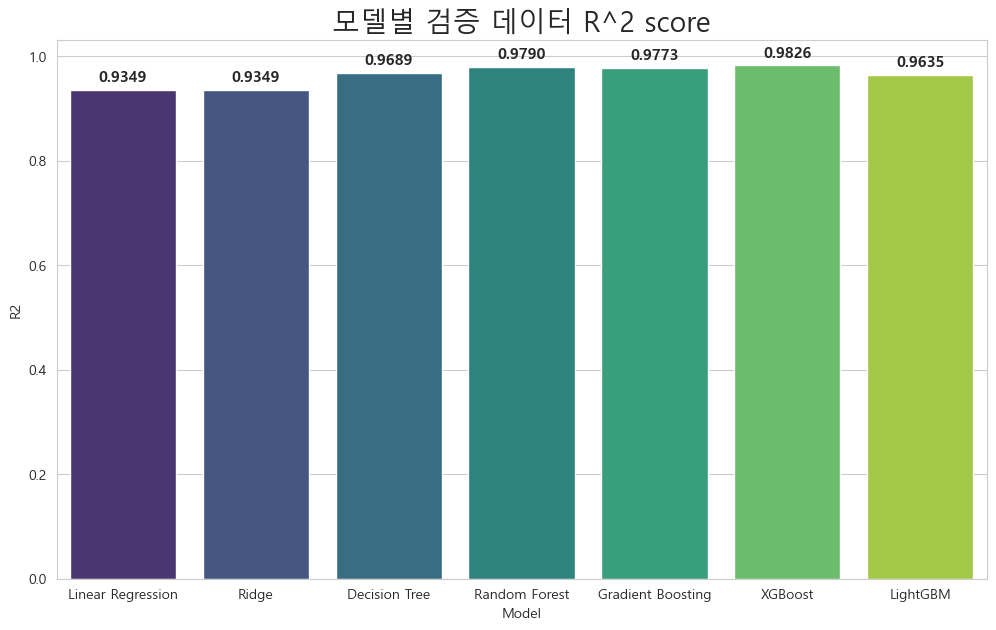

In [273]:
# 2. 막대그래프 그리기


plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
# 한글 폰트 설정 (환경에 따라 'Malgun Gothic' 또는 'AppleGothic' 사용)

plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False
plt.title('모델별 검증 데이터 R^2 score',size=20)
ax = sns.barplot(data=df_regression_results,x='Model',y='R2',palette='viridis')
# 수치 라벨 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

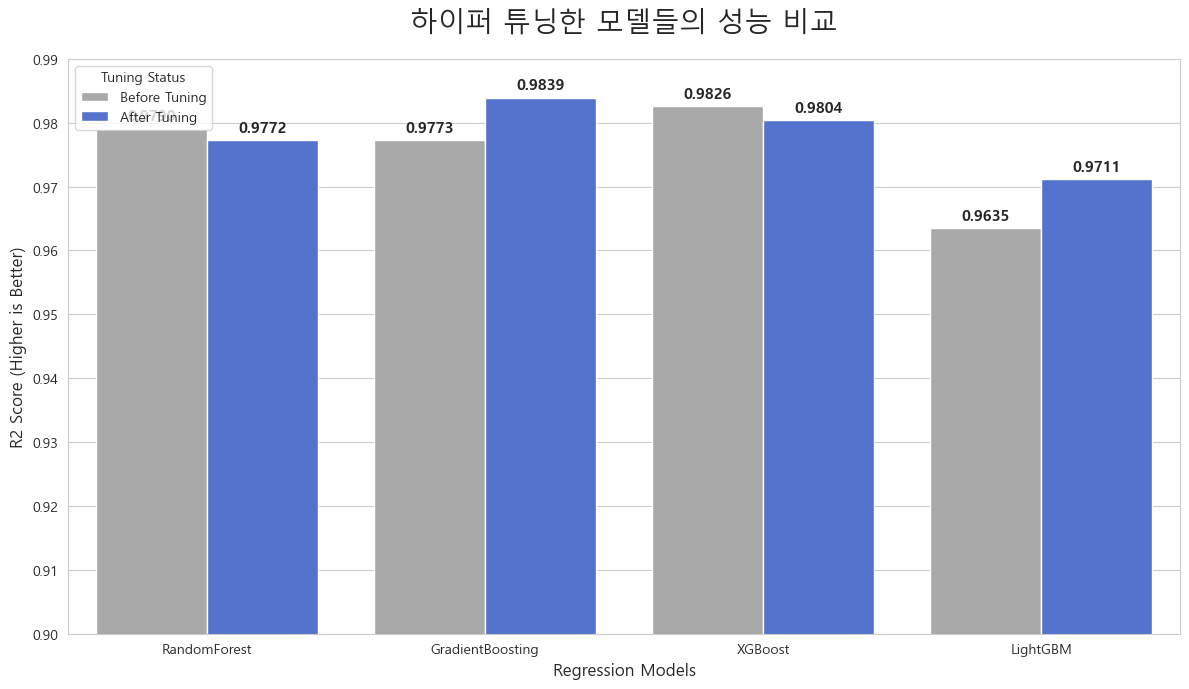

In [274]:
# 1. 시각화를 위한 데이터 전처리
# 튜닝 전 데이터에서 필요한 모델만 추출하고 이름 통일
df_before = df_regression_results[
    df_regression_results['Model'].isin(['LightGBM', 'XGBoost', 'Gradient Boosting', 'Random Forest'])
].copy()
df_before['Status'] = 'Before Tuning'
df_before['Model'] = df_before['Model'].str.replace(' ','')

# 튜닝 후 데이터 (df_results) 처리
df_after = df_results.copy()
# 'Tuned ' 접두사 제거하여 이름 통일 (예: Tuned LightGBM -> LightGBM)
df_after['Model'] = df_after['Model'].str.replace('Tuned ', '').str.replace(' (Safe)', '', regex=False)
df_after['Status'] = 'After Tuning'
# 튜닝 후 데이터는 'Test_R2'가 있다면 그것을 사용하고, 없다면 'R2'를 사용
target_col = 'Valid_R2'
df_after = df_after[['Model', target_col, 'Status']].rename(columns={target_col: 'R2'})

# 두 데이터 합치기
df_compare = pd.concat([df_before[['Model', 'R2', 'Status']], 
                        df_after[['Model', 'R2', 'Status']]], axis=0)

# 2. 막대그래프 그리기
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
# 한글 폰트 설정 (환경에 따라 'Malgun Gothic' 또는 'AppleGothic' 사용)

plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False
# 컬러 팔레트 설정
palette = {"Before Tuning": "#A9A9A9", "After Tuning": "#4169E1"}

ax = sns.barplot(data=df_compare, x='Model', y='R2', hue='Status', palette=palette)

# 3. 그래프 세부 설정
plt.title('하이퍼 튜닝한 모델들의 성능 비교', fontsize=20, pad=20)
plt.ylabel('R2 Score (Higher is Better)', fontsize=12)
plt.xlabel('Regression Models', fontsize=12)

# 차이를 명확히 보기 위해 y축 범위 조정 (이미지 수치 기반 0.90 ~ 0.97)
plt.ylim(0.90, 0.99) 

# 수치 라벨 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.legend(title='Tuning Status', loc='upper left')
plt.tight_layout()
plt.show()

In [275]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
import pandas as pd

# 1. 위에서 찾은 최적의 모델들을 기반 모델(estimators)로 설정

best_rf_model = rf_random.best_estimator_
best_gb_model = gb_random.best_estimator_
best_xgb_model = xgb_random.best_estimator_
best_lgbm_model = lgbm_random.best_estimator_
estimators = [
    ('rf', best_rf_model),
    ('gb', best_gb_model),
    ('xgb', best_xgb_model),
    ('lgbm', best_lgbm_model)
]

# 2. 스태킹 모델 정의 (최종 결합 모델은 Ridge 사용)
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

# 3. 스태킹 모델 학습
stack_model.fit(X_scaled, y_train)

# 4. 예측 및 지표 계산
y_pred_stack = stack_model.predict(X_test_scaled)

mae_stack = mean_absolute_error(y_test, y_pred_stack)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
r2_stack = r2_score(y_test, y_pred_stack)

# 5. 결과를 df_results에 추가
stack_result = pd.DataFrame([{
    'Model': 'Stacking Ensemble',
    'Best_Params': 'Final: Ridge',
    'Valid_R2': r2_stack,
    'Valid_MAE': mae_stack,
    'Valid_RMSE': rmse_stack
}])

df_results = pd.concat([df_results, stack_result], ignore_index=True)
df_results = df_results.sort_values(by='Valid_R2', ascending=False).reset_index(drop=True)

print("=== 스태킹 포함 최종 성능 비교 ===")
print(df_results)

=== 스태킹 포함 최종 성능 비교 ===
                       Model  \
0          Stacking Ensemble   
1     Tuned GradientBoosting   
2              Tuned XGBoost   
3  Tuned RandomForest (Safe)   
4             Tuned LightGBM   

                                         Best_Params  Valid_R2  Valid_MAE  \
0                                       Final: Ridge  0.993198   0.012495   
1  {'subsample': 0.9, 'n_estimators': 500, 'min_s...  0.983864   0.015840   
2  {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha...  0.980377   0.021410   
3  {'n_estimators': 500, 'min_samples_split': 2, ...  0.977241   0.017326   
4  {'subsample': 0.6, 'reg_lambda': 0.01, 'reg_al...  0.971121   0.029656   

   Valid_RMSE  
0    0.035985  
1    0.042805  
2    0.049802  
3    0.052637  
4    0.060898  


c:\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'xgboost에서의 피처 중요도')

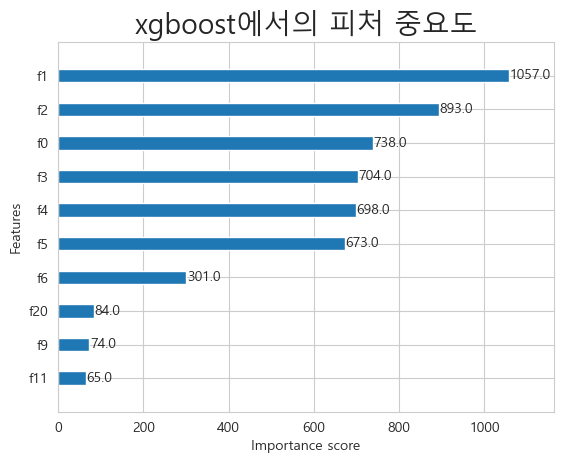

In [276]:
from xgboost import plot_importance
plot_importance(best_xgb_model,max_num_features=10,height=0.4)
plt.title('xgboost에서의 피처 중요도',size=20)

Text(0.5, 1.0, 'lightgbm에서의 피처 중요도')

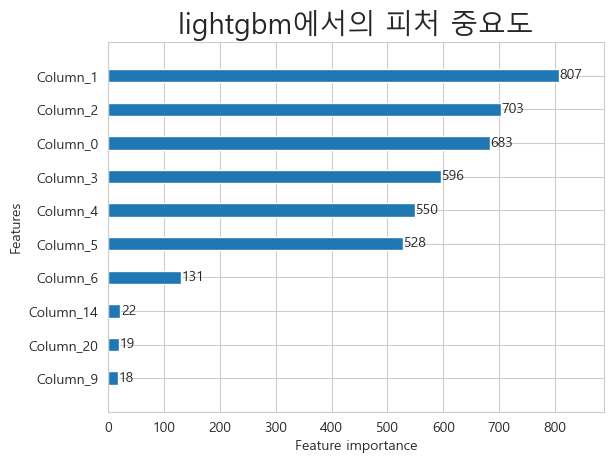

In [277]:
from lightgbm import plot_importance
plot_importance(best_lgbm_model,max_num_features=10,height=0.4)
plt.title('lightgbm에서의 피처 중요도',size=20)

C:\Users\KDS12\AppData\Local\Temp\ipykernel_23372\4185919208.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_results.sort_values(by='Valid_R2'),x='Model',y='Valid_R2',palette='viridis')


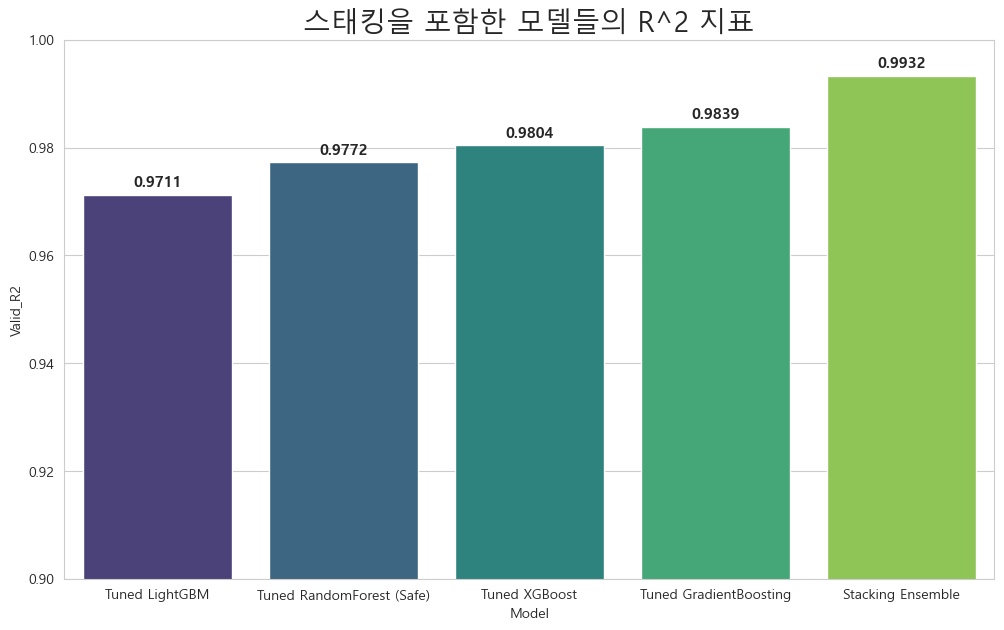

In [278]:
# 2. 막대그래프 그리기
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
# 한글 폰트 설정 (환경에 따라 'Malgun Gothic' 또는 'AppleGothic' 사용)

plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False
plt.title('스태킹을 포함한 모델들의 R^2 지표',size=20)
ax = sns.barplot(data=df_results.sort_values(by='Valid_R2'),x='Model',y='Valid_R2',palette='viridis')
plt.ylim(0.9,1.0)
# 수치 라벨 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')


C:\Users\KDS12\AppData\Local\Temp\ipykernel_23372\811470166.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=meta_importance.sort_values(by='Weight', ascending=False),


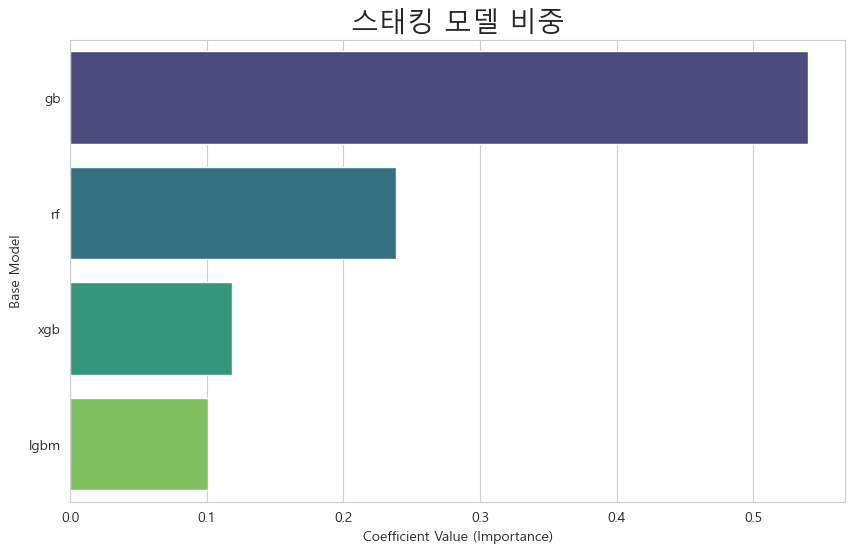

In [279]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 최종 모델(Meta-Learner)의 계수(Coefficients) 추출
# Ridge나 Lasso를 썼을 경우 coef_ 속성을 사용합니다.
meta_model = stack_model.final_estimator_
model_names = [name for name, _ in stack_model.estimators]

# 데이터프레임 생성
meta_importance = pd.DataFrame({
    'Base Model': model_names,
    'Weight': meta_model.coef_
})

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=meta_importance.sort_values(by='Weight', ascending=False), 
            x='Weight', y='Base Model', palette='viridis')
plt.title('스태킹 모델 비중',size=20)
plt.xlabel('Coefficient Value (Importance)')
plt.show()

c:\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(
C:\Users\KDS12\AppData\Local\Temp\ipykernel_23372\2987904197.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=import_df.head(20), x='Importance', y='Feature', palette='magma')


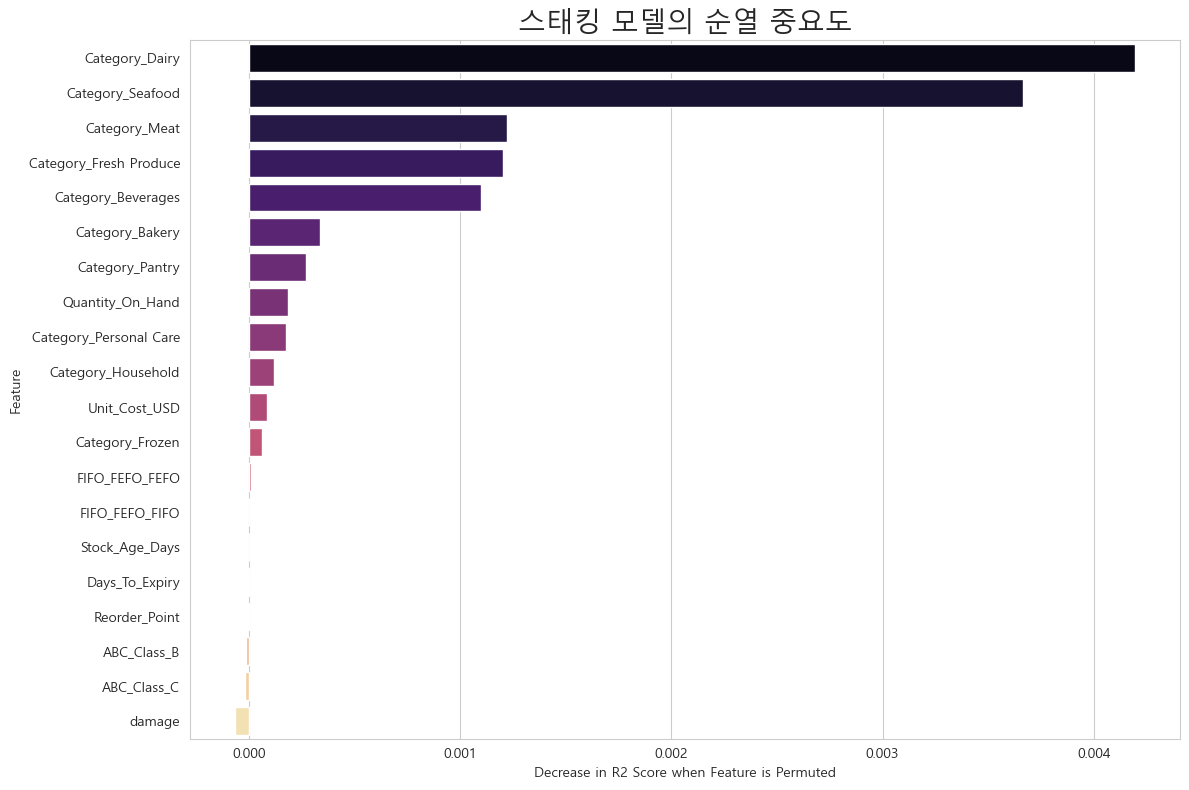

In [280]:
from sklearn.inspection import permutation_importance

# 1. Permutation Importance 계산 (시간이 조금 걸릴 수 있습니다)
# n_repeats: 무작위로 섞는 횟수
result = permutation_importance(stack_model, X_test, y_test, n_repeats=10,
                                random_state=42, n_jobs=-1)

# 2. 결과 정리
feature_names = data.columns if hasattr(data, 'columns') else [f'Feature {i}' for i in range(data.shape[1])]
sorted_idx = result.importances_mean.argsort()

import_df = pd.DataFrame({
    'Feature': [feature_names[i] for i in sorted_idx],
    'Importance': result.importances_mean[sorted_idx]
}).sort_values(by='Importance', ascending=False)

# 3. 시각화
plt.figure(figsize=(12, 8))
sns.barplot(data=import_df.head(20), x='Importance', y='Feature', palette='magma')
plt.title('스태킹 모델의 순열 중요도',size=20)
plt.xlabel('Decrease in R2 Score when Feature is Permuted')
plt.tight_layout()
plt.show()

In [281]:
y_test[y_test==1]

737    1.0
740    1.0
678    1.0
626    1.0
859    1.0
      ... 
408    1.0
332    1.0
208    1.0
613    1.0
78     1.0
Name: Target_Tight, Length: 116, dtype: float64

 [스태킹 모델: 위험 상품군(판매율 < 1.0) 성능 리포트] 
대상 샘플 수     : 84개
R² (설명력)      : 0.7124
MAE (평균 오차)  : 0.0240
RMSE (제곱근 오차): 0.0486


c:\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


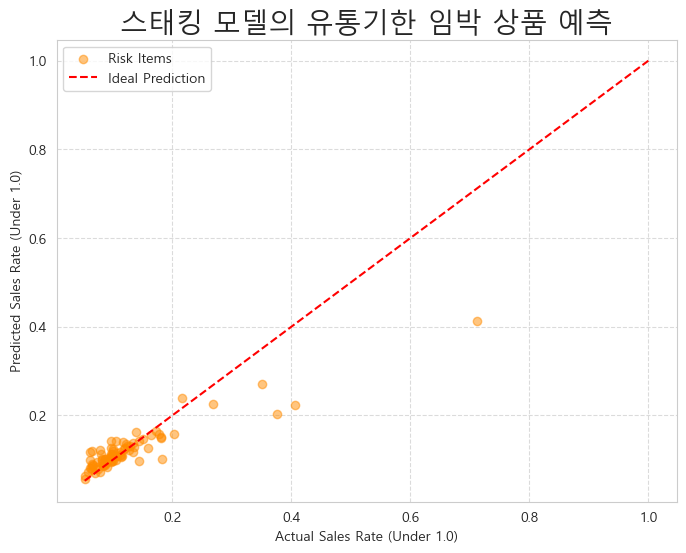

In [282]:
# 1. 스태킹 모델로 전체 테스트 데이터 예측값 생성
# (이미 stack_model.fit이 완료된 상태여야 합니다)
y_pred_stack = stack_model.predict(X_test_scaled)

# 2. 실제값이 1.0 미만인 '위험 상품군' 인덱스 추출
under_100_idx = y_test[(y_test < 1.0)].index

# 3. 위험 상품군에 해당하는 실제값과 예측값 필터링
y_test_sub = y_test.loc[under_100_idx]
# 예측값은 numpy array이므로 pandas Series로 변환하여 인덱싱 적용
y_pred_sub = pd.Series(y_pred_stack, index=y_test.index).loc[under_100_idx]

# 4. 성능 지표 계산
sub_r2 = r2_score(y_test_sub, y_pred_sub)
sub_mae = mean_absolute_error(y_test_sub, y_pred_sub)
sub_rmse = np.sqrt(mean_squared_error(y_test_sub, y_pred_sub))

# 5. 리포트 출력
print("="*45)
print(" [스태킹 모델: 위험 상품군(판매율 < 1.0) 성능 리포트] ")
print("="*45)
print(f"대상 샘플 수     : {len(under_100_idx)}개")
print(f"R² (설명력)      : {sub_r2:.4f}")
print(f"MAE (평균 오차)  : {sub_mae:.4f}")
print(f"RMSE (제곱근 오차): {sub_rmse:.4f}")
print("="*45)

# 6. 위험 상품군 전용 산점도 시각화
plt.figure(figsize=(8, 6))
plt.scatter(y_test_sub, y_pred_sub, alpha=0.5, color='darkorange', label='Risk Items')

# 기준선 (실제값 = 예측값)
plt.plot([y_test_sub.min(), 1.0], [y_test_sub.min(), 1.0], '--', color='red', label='Ideal Prediction')

plt.xlabel('Actual Sales Rate (Under 1.0)')
plt.ylabel('Predicted Sales Rate (Under 1.0)')
plt.title('스태킹 모델의 유통기한 임박 상품 예측',size=20)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [283]:
# 1. 오차 계산 (실제값 - 예측값의 절대값)
error_analysis = pd.DataFrame({
    'Actual': y_test_sub,
    'Predicted': y_pred_sub,
    'Absolute_Error': np.abs(y_test_sub - y_pred_sub)
}, index=under_100_idx)

# 2. 오차 상위 10개 인덱스 추출
top_10_error_idx = error_analysis.sort_values(by='Absolute_Error', ascending=False).head(10).index

# 3. 원본 피처와 결합 (원본 데이터프레임이 df_raw라고 가정, 인덱스가 유지된 경우)
# 분석하고 싶은 주요 피처들을 선택하세요 (예: 'Category', 'Price', 'Stock', 등)
features_to_check = ['Category', 'Price', 'Discount_Rate', 'Inventory_Level'] # 예시 피처명
top_10_details = X_test.loc[top_10_error_idx].copy()

# 결과 합치기
top_10_report = pd.concat([error_analysis.loc[top_10_error_idx], top_10_details], axis=1)

print("="*50)
print(" [오차 상위 10개 위험 상품 상세 분석] ")
print("="*50)
print(top_10_report)

 [오차 상위 10개 위험 상품 상세 분석] 
       Actual  Predicted  Absolute_Error  Stock_Age_Days  Quantity_On_Hand  \
998  0.711515   0.413283        0.298233             125                33   
936  0.405536   0.222862        0.182674               5                56   
256  0.375143   0.203464        0.171679             112                35   
973  0.183208   0.101780        0.081428              15               106   
689  0.350904   0.270601        0.080303              31               177   
259  0.061294   0.117440        0.056146             104                85   
959  0.064310   0.118988        0.054678              76                58   
534  0.143041   0.097894        0.045147              13               171   
521  0.077692   0.122807        0.045114              59                52   
184  0.097083   0.142084        0.045001              81                48   

     Avg_Daily_Sales  Reorder_Point  Unit_Cost_USD  Days_To_Expiry  damage  \
998            23.48          181.0  

In [236]:
# 1. 원-핫 인코딩된 컬럼들만 리스트로 추출 (컬럼명이 'Category_'로 시작한다고 가정)
X_test_scaled = pd.DataFrame(X_test_scaled)
category_cols = [col for col in X_test_scaled.columns if col.startswith('Category_')]

# 2. 1이 있는 위치의 컬럼명을 찾아 'Category' 컬럼 생성
# 예: 'Category_Food' 컬럼이 1이면 -> 값은 'Food'가 됨
X_test_temp = X_test_scaled.copy()
X_test_temp['Category'] = X_test_scaled[category_cols].idxmax(axis=1).str.replace('Category_', '')

# 3. 오차 데이터와 결합하여 분석
error_analysis_with_cat = error_analysis.join(X_test_temp['Category'])

# 4. 시각화 (앞서 드린 박스플롯 코드 그대로 사용 가능)
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(data=error_analysis_with_cat, x='Category', y='Absolute_Error')
plt.xticks(rotation=45)
plt.title('Error Distribution by Category (Recovered from One-Hot)')
plt.show()

AttributeError: 'int' object has no attribute 'startswith'

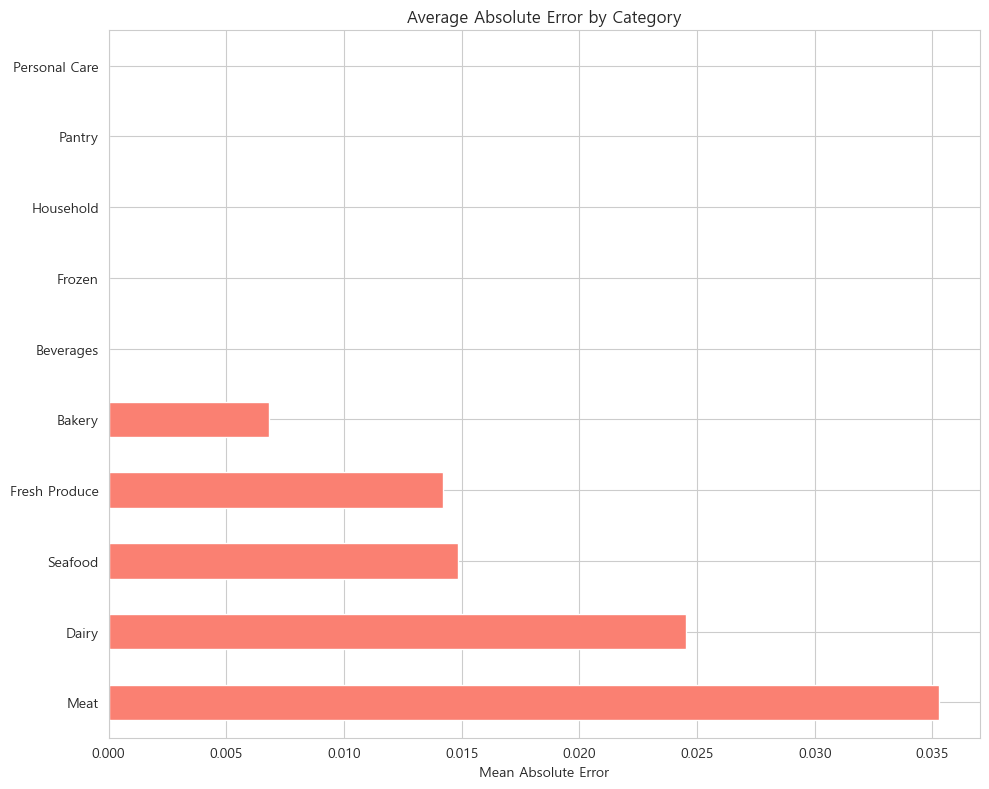

In [ ]:
# 각 카테고리별 평균 오차 계산
category_errors = {}
for col in category_cols:
    # 해당 카테고리가 1인 데이터들의 평균 오차
    avg_error = error_analysis.loc[X_test[col] == 1, 'Absolute_Error'].mean()
    category_errors[col.replace('Category_', '')] = avg_error

# 데이터프레임으로 변환 후 시각화
error_by_cat = pd.Series(category_errors).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
error_by_cat.plot(kind='barh', color='salmon')
plt.title('Average Absolute Error by Category')
plt.xlabel('Mean Absolute Error')
plt.tight_layout()
plt.show()

In [284]:
# 1. 기존에 구한 스태킹 모델로 판매율 예측 (이미 예측값이 있다면 생략 가능)
# X_full은 이전에 정의한 전처리가 완료된 전체 특성 데이터입니다.
df2['Predicted_Sell_Rate'] = stack_model.predict(data_scaled).clip(0, 1)

# 2. 기본 비즈니스 파라미터 설정
MARKUP_RATE = 0.40          # 기본 마진율 40%
DISPOSAL_FEE_RATE = 0.10     # 폐기 시 발생하는 추가 비용 (원가의 10%)
RECOVERY_EFFICIENCY = 0.85   # 할인 적용 시 폐기 예정 물량의 85%가 판매된다고 가정

# 가격 및 폐기 비용 컬럼 생성
df2['Unit_Price_USD'] = df2['Unit_Cost_USD'] * (1 + MARKUP_RATE)
df2['Unit_Waste_Cost_USD'] = df2['Unit_Cost_USD'] * (1 + DISPOSAL_FEE_RATE)

# 3. 시나리오 비교 함수 정의
def run_profit_simulation(row):
    # 공통 데이터
    qty = row['Quantity_On_Hand']
    cost = row['Unit_Cost_USD']
    price = row['Unit_Price_USD']
    pred_rate = row['Predicted_Sell_Rate']
    
    # --- [시나리오 A: 할인 없음 (Baseline)] ---
    a_sold_qty = qty * pred_rate
    a_waste_qty = qty - a_sold_qty
    
    a_revenue = a_sold_qty * price
    # 이익 = 매출 - 판매분 원가 - 폐기분 원가 및 처리비
    a_profit = a_revenue - (a_sold_qty * cost) - (a_waste_qty * row['Unit_Waste_Cost_USD'])
    
    # --- [시나리오 B: 전략적 할인 적용 (Optimized)] ---
    # 할인율 결정 로직
    if pred_rate >= 0.90:
        discount = 0.0
        action = "정상가 유지"
    elif pred_rate >= 0.60:
        discount = 0.20
        action = "20% 세일"
    elif pred_rate >= 0.30:
        discount = 0.40
        action = "40% 균일가"
    else:
        discount = 0.60
        action = "60% 덤핑"
        
    discounted_price = price * (1 - discount)
    
    # 할인 후 판매량: 기존 판매량 + (폐기 예정 물량 * 회수 효율)
    # 단, 전체 재고량을 초과할 수 없음
    b_sold_qty = min(qty, a_sold_qty + (a_waste_qty * RECOVERY_EFFICIENCY))
    b_waste_qty = qty - b_sold_qty
    
    b_revenue = b_sold_qty * discounted_price
    b_profit = b_revenue - (b_sold_qty * cost) - (b_waste_qty * row['Unit_Waste_Cost_USD'])
    
    return pd.Series([a_revenue, a_profit, b_revenue, b_profit, action, discount])

# 4. 시뮬레이션 실행 및 결과 결합
cols = ['Base_Revenue', 'Base_Profit', 'Opt_Revenue', 'Opt_Profit', 'Action', 'Discount_Rate']
df2[cols] = df2.apply(run_profit_simulation, axis=1)

# 5. 최종 성과 요약 리포트
total_base_rev = df2['Base_Revenue'].sum()
total_opt_rev = df2['Opt_Revenue'].sum()
total_base_profit = df2['Base_Profit'].sum()
total_opt_profit = df2['Opt_Profit'].sum()

print("="*50)
print(f"  [ 유통기한 임박 재고 최적화 시뮬레이션 결과 ]")
print("="*50)
print(f"1. 매출 변화: ${total_base_rev:,.2f} ➔ ${total_opt_rev:,.2f} ({((total_opt_rev-total_base_rev)/total_base_rev*100):+.1f}%)")
print(f"2. 순이익 변화: ${total_base_profit:,.2f} ➔ ${total_opt_profit:,.2f} ({((total_opt_profit-total_base_profit)/abs(total_base_profit)*100):+.1f}%)")
print(f"3. 총 폐기 방어 금액: ${ (total_opt_profit - total_base_profit):,.2f}")
print("="*50)

# 이익 개선 효과가 큰 상위 10개 품목 확인
df2['Profit_Delta'] = df2['Opt_Profit'] - df2['Base_Profit']
display(df2.sort_values(by='Profit_Delta', ascending=False)[['Category', 'Quantity_On_Hand', 'Remaining_Shelf_Days', 'Predicted_Sell_Rate', 'Action', 'Profit_Delta']].head(10))

c:\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  [ 유통기한 임박 재고 최적화 시뮬레이션 결과 ]
1. 매출 변화: $1,138,536.16 ➔ $1,267,543.84 (+11.3%)
2. 순이익 변화: $-51,825.78 ➔ $106,323.13 (+305.2%)
3. 총 폐기 방어 금액: $158,148.91


,Category,Quantity_On_Hand,Remaining_Shelf_Days,Predicted_Sell_Rate,Action,Profit_Delta
105,Meat,415,-61,0.079661,60% 덤핑,2062.677368
838,Meat,412,-142,0.068186,60% 덤핑,2057.738233
254,Meat,595,-99,0.055603,60% 덤핑,1983.365563
3,Seafood,281,-84,0.093070,60% 덤핑,1754.516566
562,Seafood,393,-106,0.072203,60% 덤핑,1631.888668
793,Meat,722,-34,0.053042,60% 덤핑,1563.678180
62,Dairy,858,-117,0.068754,60% 덤핑,1511.039992
582,Dairy,864,-95,0.069084,60% 덤핑,1439.880123
473,Bakery,759,-153,0.059762,60% 덤핑,1420.021750
395,Meat,336,-137,0.117334,60% 덤핑,1407.252404


C:\Users\KDS12\AppData\Local\Temp\ipykernel_23372\1705431057.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_delta, x='Profit_Delta', y='Category', ax=ax[1], palette='magma')


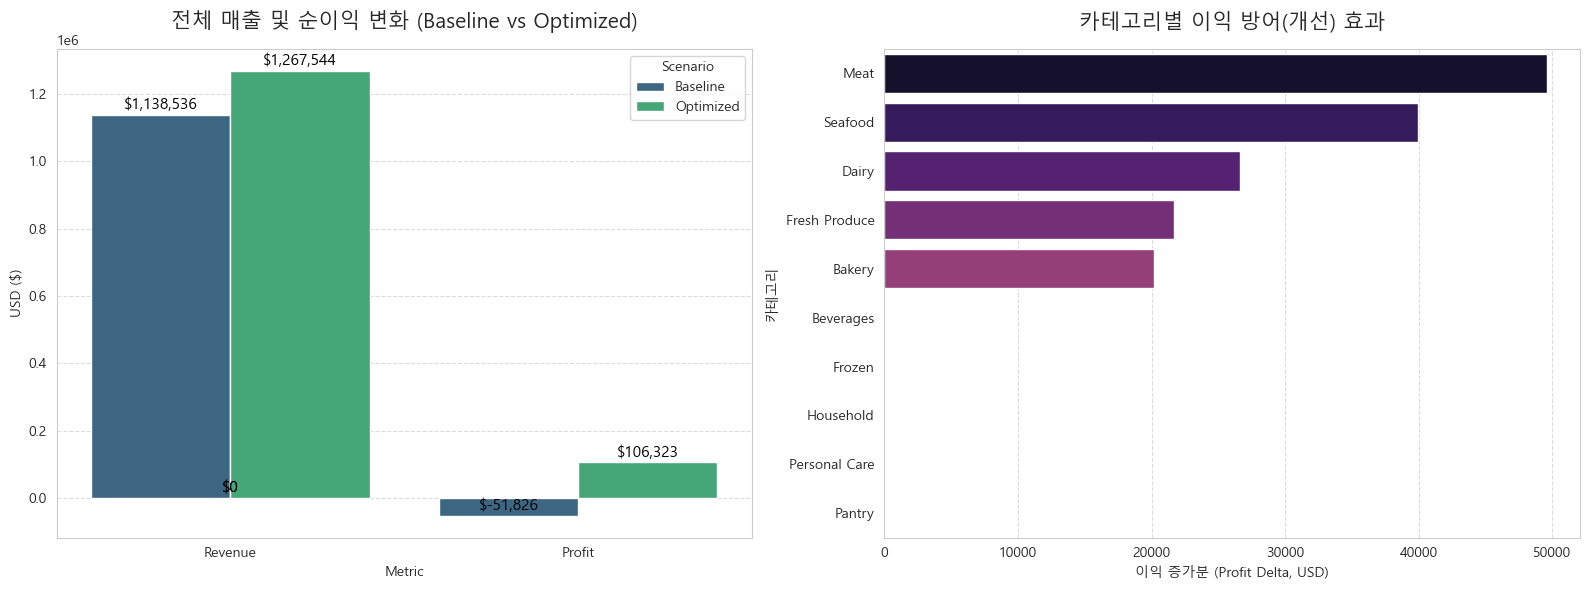

In [285]:
# 1. 데이터 집계 (전체 합계 비교)

# 한글 폰트 설정 (환경에 따라 'Malgun Gothic' 또는 'AppleGothic' 사용)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False
totals = pd.DataFrame({
    'Metric': ['Revenue', 'Revenue', 'Profit', 'Profit'],
    'Scenario': ['Baseline', 'Optimized', 'Baseline', 'Optimized'],
    'Value': [total_base_rev, total_opt_rev, total_base_profit, total_opt_profit]
})

# 2. 대시보드 레이아웃 설정 (1행 2열)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- [그래프 1] 전체 매출 및 순이익 비교 ---
sns.barplot(data=totals, x='Metric', y='Value', hue='Scenario', ax=ax[0], palette='viridis')
ax[0].set_title('전체 매출 및 순이익 변화 (Baseline vs Optimized)', fontsize=15, pad=15)
ax[0].set_ylabel('USD ($)')

# 값 표시 (Bar 위에 수치 표기)
for p in ax[0].patches:
    ax[0].annotate(f'${p.get_height():,.0f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', fontsize=11, color='black', xytext=(0, 7),
                   textcoords='offset points')

# --- [그래프 2] 카테고리별 이익 개선액 (Profit Delta) ---
# 카테고리별로 이익이 얼마나 방어되었는지 합계 계산
cat_delta = df2.groupby('Category')['Profit_Delta'].sum().sort_values(ascending=False).reset_index()

sns.barplot(data=cat_delta, x='Profit_Delta', y='Category', ax=ax[1], palette='magma')
ax[1].set_title('카테고리별 이익 방어(개선) 효과', fontsize=15, pad=15)
ax[1].set_xlabel('이익 증가분 (Profit Delta, USD)')
ax[1].set_ylabel('카테고리')

# 격자 추가 및 간격 조정
ax[0].grid(axis='y', linestyle='--', alpha=0.7)
ax[1].grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

c:\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


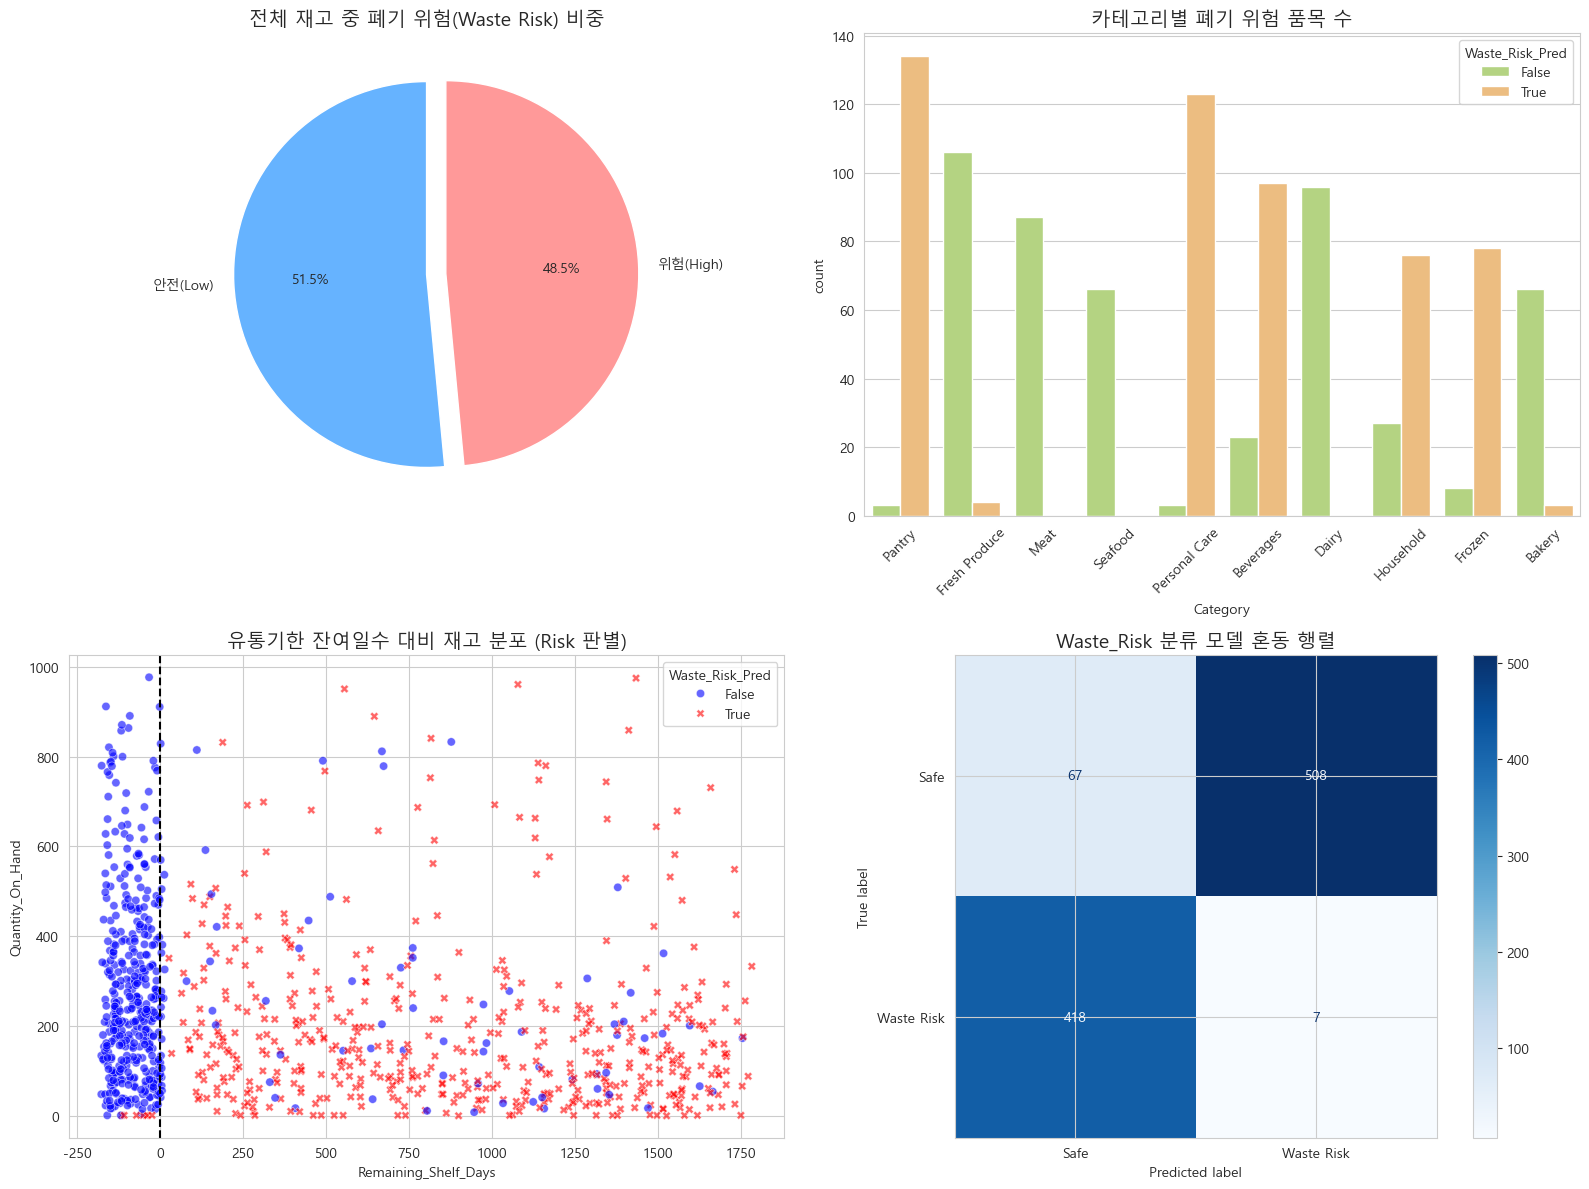

In [287]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 준비 (분류 모델의 예측값이 'Waste_Risk_Pred' 컬럼에 있다고 가정)
# 예시를 위해 임의의 예측값 생성 (실제 코드에서는 모델의 predict 결과 사용)
df2['Waste_Risk_Pred'] = stack_model.predict(data_scaled) > 1 # 회수율 기반 혹은 분류기 결과

# 2. 대시보드 레이아웃 (2행 2열)
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# --- [그래프 1] Waste_Risk 비중 (Pie Chart) ---
risk_counts = df2['Waste_Risk_Pred'].value_counts()
ax[0, 0].pie(risk_counts, labels=['안전(Low)', '위험(High)'], autopct='%1.1f%%', 
             startangle=90, colors=['#66b3ff','#ff9999'], explode=(0, 0.1))
ax[0, 0].set_title('전체 재고 중 폐기 위험(Waste Risk) 비중', fontsize=14)

# --- [그래프 2] 카테고리별 Waste_Risk 발생 건수 (Count Plot) ---
sns.countplot(data=df2, x='Category', hue='Waste_Risk_Pred', ax=ax[0, 1], palette='RdYlGn_r')
ax[0, 1].set_title('카테고리별 폐기 위험 품목 수', fontsize=14)
ax[0, 1].tick_params(axis='x', rotation=45)

# --- [그래프 3] 잔여 유통기한 vs 재고량 (Scatter Plot) ---
# 위험군(1)인 상품들이 실제로 어디에 분포하는지 시각화
sns.scatterplot(data=df2, x='Remaining_Shelf_Days', y='Quantity_On_Hand', 
                hue='Waste_Risk_Pred', style='Waste_Risk_Pred', 
                palette={True: 'red', False: 'blue'}, alpha=0.6, ax=ax[1, 0])
ax[1, 0].axvline(x=0, color='black', linestyle='--') # 유통기한 경과선
ax[1, 0].set_title('유통기한 잔여일수 대비 재고 분포 (Risk 판별)', fontsize=14)

# --- [그래프 4] 혼동 행렬 (Confusion Matrix) ---
# 모델의 예측 정확도를 평가 (실제값 y_test와 예측값 y_pred 필요)
cm = confusion_matrix(df2['Waste_Risk'], df2['Waste_Risk_Pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Waste Risk'])
disp.plot(ax=ax[1, 1], cmap='Blues')
ax[1, 1].set_title('Waste_Risk 분류 모델 혼동 행렬', fontsize=14)

plt.tight_layout()
plt.show()

 [위험 상품군(판매율 < 1.0) 성능 리포트] 
대상 샘플 수    : 84개
R² (설명력)     : 0.7206
MAE (평균 오차)  : 0.0223
RMSE (제곱근 오차): 0.0479


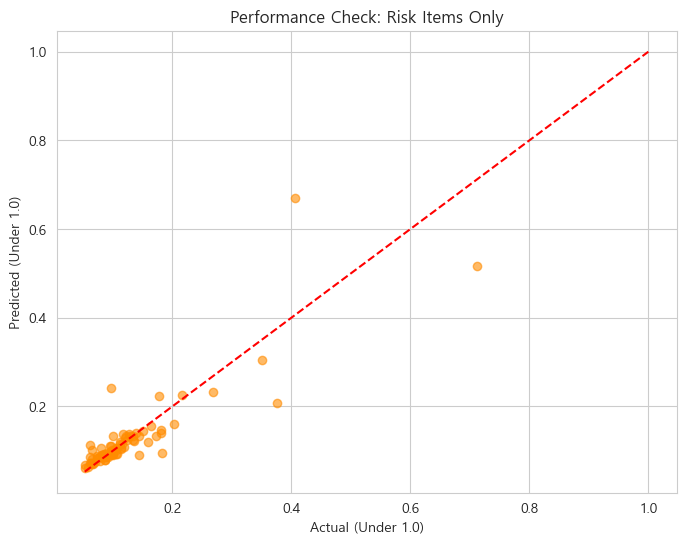

In [ ]:
# 1. 예측값 생성 (최적화된 모델 best_rf 사용 가정)
sample_weights = np.where(y_train < 1.0, 5.0, 1.0)
xgb = XGBRegressor(random_state=42, n_jobs=-1)
xgb.fit(X_scaled,y_train,sample_weight=sample_weights)

y_pred = xgb.predict(X_test)

# 1. 실제값이 1.0 미만인 인덱스만 추출
under_100_idx = y_test[(y_test < 1.0)].index

y_test_sub = y_test.loc[under_100_idx]
y_pred_sub = pd.Series(y_pred, index=y_test.index).loc[under_100_idx]

# 2. 성능 지표 계산
sub_r2 = r2_score(y_test_sub, y_pred_sub)
sub_mae = mean_absolute_error(y_test_sub, y_pred_sub)
sub_rmse = np.sqrt(mean_squared_error(y_test_sub, y_pred_sub))

# 3. 리포트 출력
print("="*40)
print(" [위험 상품군(판매율 < 1.0) 성능 리포트] ")
print("="*40)
print(f"대상 샘플 수    : {len(under_100_idx)}개")
print(f"R² (설명력)     : {sub_r2:.4f}")
print(f"MAE (평균 오차)  : {sub_mae:.4f}")
print(f"RMSE (제곱근 오차): {sub_rmse:.4f}")
print("="*40)

# 4. 위험 상품군 전용 산점도 시각화
plt.figure(figsize=(8, 6))
plt.scatter(y_test_sub, y_pred_sub, alpha=0.6, color='darkorange')
plt.plot([y_test_sub.min(), 1], [y_test_sub.min(), 1], '--', color='red')
plt.xlabel('Actual (Under 1.0)')
plt.ylabel('Predicted (Under 1.0)')
plt.title('Performance Check: Risk Items Only')
plt.show()

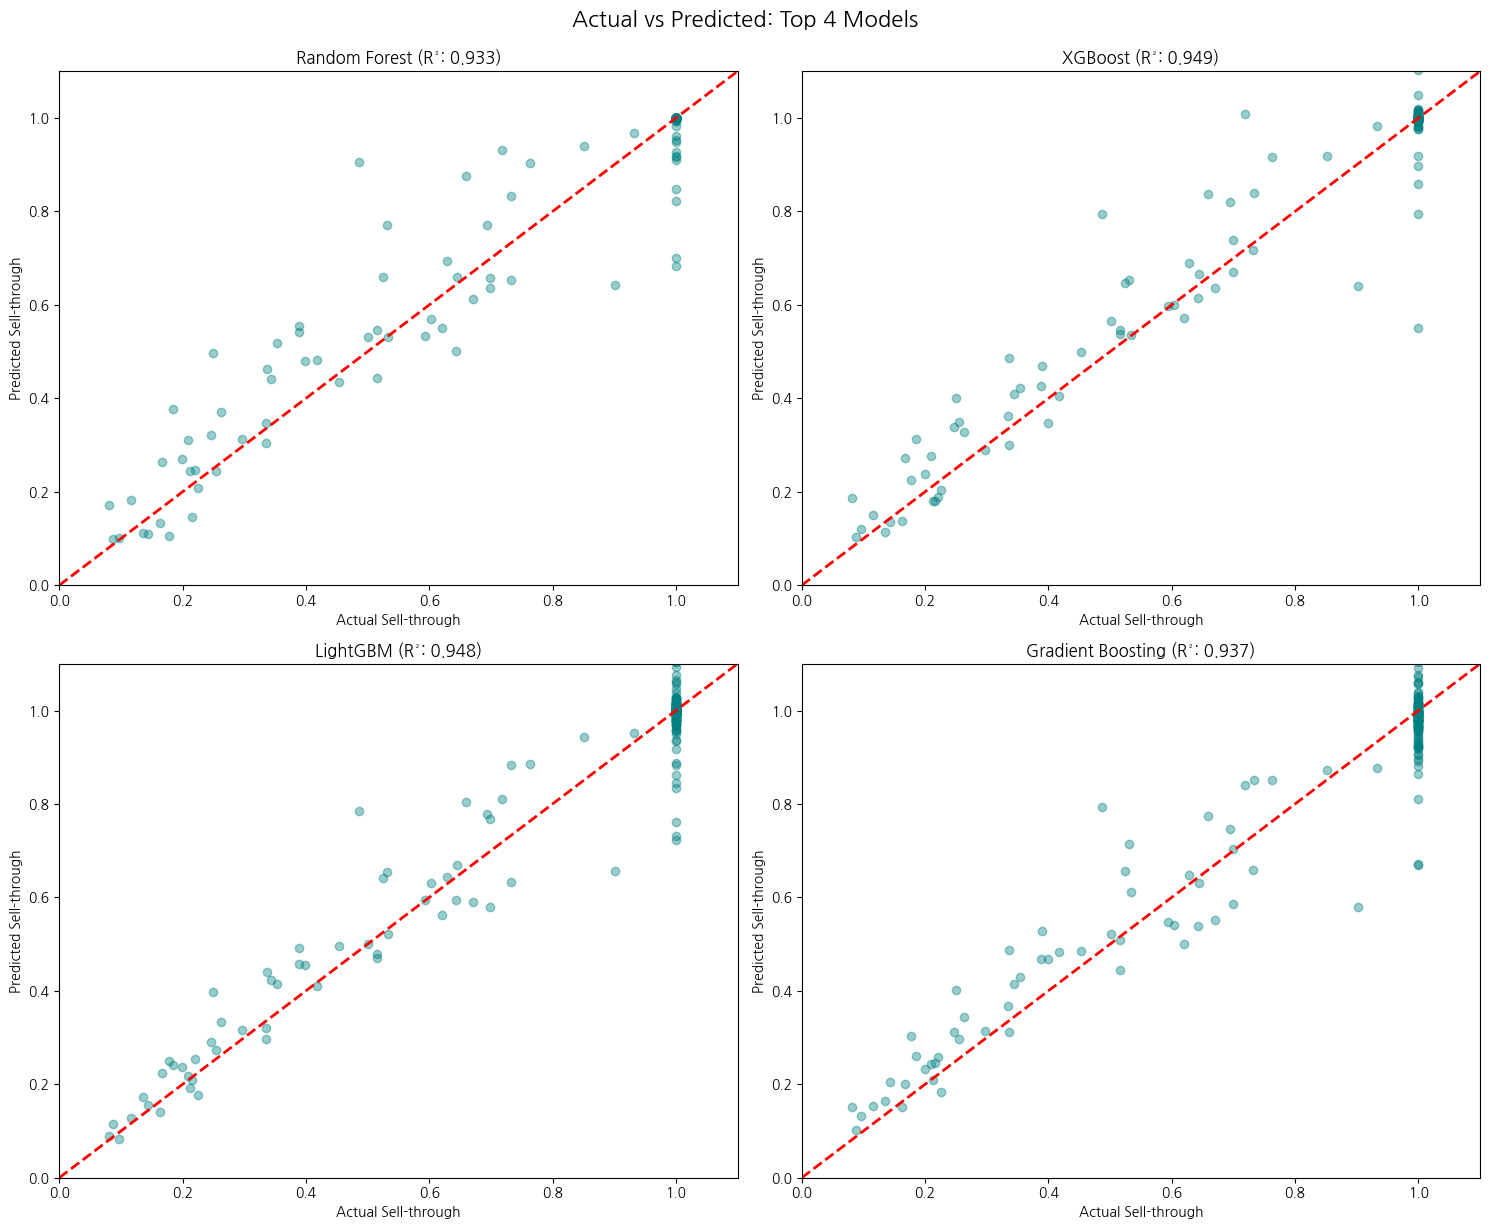

C:\Users\KDS12\AppData\Local\Temp\ipykernel_4440\931813464.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2', y='Model', data=df_results_sorted, palette='viridis')


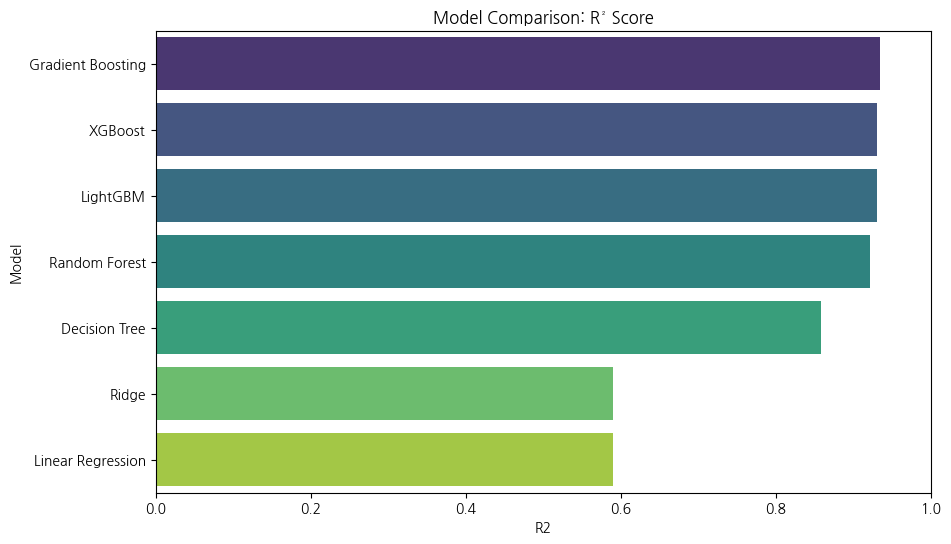

In [ ]:
# 시각화를 위한 설정
models_to_plot = [
    ('Random Forest', RandomForestRegressor(random_state=42, n_jobs=-1)),
    ('XGBoost', XGBRegressor(random_state=42, n_jobs=-1)),
    ('LightGBM', LGBMRegressor(random_state=42, n_jobs=-1)),
    ('Gradient Boosting', GradientBoostingRegressor(random_state=42))
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(models_to_plot):
    # 모델 학습 (가중치 적용)
    model.fit(X_scaled, y_train, sample_weight=sample_weights)
    y_pred = model.predict(X_test)
    
    # 산점도 그리기
    axes[i].scatter(y_test, y_pred, alpha=0.4, color='teal')
    axes[i].plot([0, 1.2], [0, 1.2], '--', color='red', linewidth=2) # 기준선
    axes[i].set_title(f'{name} (R²: {r2_score(y_test, y_pred):.3f})')
    axes[i].set_xlabel('Actual Sell-through')
    axes[i].set_ylabel('Predicted Sell-through')
    axes[i].set_xlim(0, 1.1)
    axes[i].set_ylim(0, 1.1)

plt.tight_layout()
plt.suptitle('Actual vs Predicted: Top 4 Models', y=1.02, fontsize=16)
plt.show()

# 2. 전체 모델 지표 비교 차트
plt.figure(figsize=(10, 6))
df_results_sorted = df_regression_results.sort_values(by='R2', ascending=False)
sns.barplot(x='R2', y='Model', data=df_results_sorted, palette='viridis')
plt.title('Model Comparison: R² Score')
plt.xlim(0, 1.0)
plt.show()

In [ ]:
df5 = df2.copy()
# df4 = df4[df4['Remaining_Shelf_Days']>=0]
target = df5['damage']
df5 = df5.drop(columns=['Days_of_Inventory','Days_To_Deplete','Remaining_Shelf_Days','Waste_Risk','Received_Date','Expiry_Date','sell_rate','Target_Tight','DTE_Tight','Damaged_Qty','Returns_Qty','damage'])
df5.select_dtypes('timedelta').astype(float)
data = pd.get_dummies(df5,columns=['Category','ABC_Class','FIFO_FEFO'],dtype=int)

print(data.info())
print(target)
X_scaled,X_test,y_train,y_test = train_test_split(data,target,test_size=0.2,random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled_scaled = scaler.fit_transform(X_scaled)
X_test_scaled = scaler.transform(X_test)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Stock_Age_Days          1000 non-null   int64  
 1   Quantity_On_Hand        1000 non-null   int64  
 2   Avg_Daily_Sales         1000 non-null   float64
 3   Reorder_Point           1000 non-null   float64
 4   Unit_Cost_USD           1000 non-null   float64
 5   Days_To_Expiry          1000 non-null   int64  
 6   Category_Bakery         1000 non-null   int64  
 7   Category_Beverages      1000 non-null   int64  
 8   Category_Dairy          1000 non-null   int64  
 9   Category_Fresh Produce  1000 non-null   int64  
 10  Category_Frozen         1000 non-null   int64  
 11  Category_Household      1000 non-null   int64  
 12  Category_Meat           1000 non-null   int64  
 13  Category_Pantry         1000 non-null   int64  
 14  Category_Personal Care  1000 non-null   i

In [ ]:
# 2. 샘플 가중치 생성 (위험 상품군에 5배 가중치)
# 판매율이 낮을수록(위험할수록) 더 중요하게 학습하도록 설정
sample_weights = np.where(y_train >0, 5.0, 1.0)

# 3. 평가할 회귀 모델 리스트
models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge', Ridge(random_state=42)),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42, n_jobs=-1)),
    ('Gradient Boosting', GradientBoostingRegressor(random_state=42)),
    ('XGBoost', XGBRegressor(random_state=42, n_jobs=-1)),
    ('LightGBM', LGBMRegressor(random_state=42, n_jobs=-1))
]
kf = KFold(shuffle=True,random_state=42)
results_list = []

# 4. 모델별 학습 및 지표 출력
print(f"{'Model':<20} | {'R2':<8} | {'MAE':<8} | {'RMSE':<8}")
print("-" * 55)

for name, model in models:
    fold_r2,fold_mae,fold_rmse=[],[],[]
    for train_index,val_index in kf.split(X_scaled):
        X_tr,X_valid = X_scaled.iloc[train_index],X_scaled.iloc[val_index]
        y_tr,y_valid = y_train.iloc[train_index],y_train.iloc[val_index]
        w_t = sample_weights[train_index]
        
        try:
            model.fit(X_tr,y_tr)
        except:
            model.fit(X_tr,y_tr)
        
        preds = model.predict(X_valid)
        fold_r2.append(r2_score(y_valid,preds))
        fold_mae.append(mean_absolute_error(y_valid,preds))
        fold_rmse.append(np.sqrt(mean_squared_error(y_valid,preds)))
        
    print(f"{name:<20} | {np.mean(fold_r2):.4f}   | {np.mean(fold_mae):.4f}   | {np.mean(fold_rmse):.4f}")
    results_list.append({
        'Model': name,
        'R2': np.mean(fold_r2),
        'MAE': np.mean(fold_mae),
        'RMSE': np.mean(fold_rmse)
    })

# 5. 결과 저장 및 확인
df_regression_results = pd.DataFrame(results_list)

Model                | R2       | MAE      | RMSE    
-------------------------------------------------------
Linear Regression    | -0.0415   | 1.2857   | 1.6015
Ridge                | -0.0403   | 1.2847   | 1.6007
Decision Tree        | -1.0686   | 1.7125   | 2.2488
Random Forest        | -0.0884   | 1.3166   | 1.6359
Gradient Boosting    | -0.1219   | 1.3267   | 1.6610
XGBoost              | -0.3521   | 1.4426   | 1.8231
LightGBM             | -0.2162   | 1.3723   | 1.7270


In [ ]:

from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# 1. 모델 정의 및 학습 (가중치 적용)
# 이전 비교에서 가장 우수했던 하이퍼파라미터나 기본 설정을 사용합니다.
xgb_reg = XGBRegressor(n_estimators=300, max_depth=7, learning_rate=0.05, random_state=42, n_jobs=-1)

# 가중치 재계산 (y_train이 Target_Tight 기준일 때)
sample_weights = np.where(y_train < 1.0, 5.0, 1.0)

# 모델 학습
xgb_reg.fit(X_scaled, y_train, sample_weight=sample_weights)

# 2. 전체 데이터에 대한 예측 수행
# X는 전처리가 완료된 전체 특성 데이터프레임입니다.
all_preds = xgb_reg.predict(data)

# 3. 리포트 생성을 위한 데이터 정리
report_df = df4.copy()
report_df['Predicted_Sell_Rate'] = all_preds
# 0 미만이나 1 초과 값 보정
report_df['Predicted_Sell_Rate'] = report_df['Predicted_Sell_Rate'].clip(0, 1)

# 폐기 예상 수량 및 손실액 계산
report_df['Expected_Waste_Qty'] = (report_df['Quantity_On_Hand'] * (1 - report_df['Predicted_Sell_Rate']))
report_df['Potential_Loss_USD'] = report_df['Expected_Waste_Qty'] * report_df['Unit_Cost_USD']

# 4. 권장 할인율 로직 (보수적 접근)
def suggest_discount(row):
    if row['Predicted_Sell_Rate'] >= 0.90: return "0% (정상가)"
    elif row['Predicted_Sell_Rate'] >= 0.60: return "20% (세일)"
    elif row['Predicted_Sell_Rate'] >= 0.30: return "40% (균일가)"
    else: return "60% (마감덤핑)"

report_df['Suggested_Action'] = report_df.apply(suggest_discount, axis=1)

# 5. 최종 리포트 출력 (위험 상품 Top 10)
risk_items = report_df[report_df['Predicted_Sell_Rate'] < 1.0].sort_values(by='Potential_Loss_USD', ascending=False)

# print("="*30, "[ 실시간 재고 구출 대시보드 ]", "="*30)
# display(risk_items[['SKU_Name', 'Category', 'Quantity_On_Hand', 'Days_To_Expiry', 
#                     'Predicted_Sell_Rate', 'Potential_Loss_USD', 'Suggested_Action']].head(10))

# 6. 기대 효과 요약
total_loss = report_df['Potential_Loss_USD'].sum()
print(f"\n💡 전체 재고 중 잠재적 손실 위험액: ${total_loss:,.2f}")
print(f"💡 모델 권장 액션 이행 시 예상 방어 금액: ${total_loss * 0.7:,.2f} (회수율 70% 가정)")
report_df

ValueError: feature_names mismatch: ['Stock_Age_Days', 'Quantity_On_Hand', 'Avg_Daily_Sales', 'Reorder_Point', 'Unit_Cost_USD', 'Days_To_Expiry', 'Category_Bakery', 'Category_Beverages', 'Category_Dairy', 'Category_Fresh Produce', 'Category_Frozen', 'Category_Household', 'Category_Meat', 'Category_Pantry', 'Category_Personal Care', 'Category_Seafood', 'ABC_Class_A', 'ABC_Class_B', 'ABC_Class_C', 'FIFO_FEFO_FEFO', 'FIFO_FEFO_FIFO'] ['Stock_Age_Days', 'Quantity_On_Hand', 'Avg_Daily_Sales', 'Reorder_Point', 'Unit_Cost_USD', 'Days_To_Expiry', 'damage', 'Category_Bakery', 'Category_Beverages', 'Category_Dairy', 'Category_Fresh Produce', 'Category_Frozen', 'Category_Household', 'Category_Meat', 'Category_Pantry', 'Category_Personal Care', 'Category_Seafood', 'ABC_Class_A', 'ABC_Class_B', 'ABC_Class_C', 'FIFO_FEFO_FEFO', 'FIFO_FEFO_FIFO']
training data did not have the following fields: damage

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)

# 분할기 고정
kf = KFold(shuffle=True,random_state=42)

scores = cross_validate(dt,X_scaled,y_train,return_train_score=True,n_jobs=-1,cv=kf)
print('트레이닝 세트 정확도:',np.mean(scores['train_score']))
print('검증 세트 정확도: ', np.mean(scores['test_score']))
dt_score = np.mean(scores['test_score'])

트레이닝 세트 정확도: 1.0
검증 세트 정확도:  0.8329884136795052


In [ ]:
# 2. 샘플 가중치 계산
# 판매율이 1.0 미만인 샘플에 5배의 중요도를 부여합니다.
sample_weights = np.where(y_train < 1.0, 5.0, 1.0)

# 3. 모델 학습 (가중치 적용)
rf_tight = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf_tight.fit(X_scaled, y_train, sample_weight=sample_weights)

# 4. 성능 측정 (위험군 전용)
y_pred = rf_tight.predict(X_test)
under_1_idx = y_test[y_test < 1.0].index

if len(under_1_idx) > 0:
    y_test_risk = y_test.loc[under_1_idx]
    y_pred_risk = pd.Series(y_pred, index=y_test.index).loc[under_1_idx]
    
    print(f"새로운 위험군 샘플 수: {len(under_1_idx)}개")
    print(f"위험군 R² 점수: {r2_score(y_test_risk, y_pred_risk):.4f}")
    print(f"위험군 MAE: {mean_absolute_error(y_test_risk, y_pred_risk):.4f}")
else:
    print("여전히 위험군 샘플이 부족합니다. 마진을 더 늘려야 합니다.")

새로운 위험군 샘플 수: 56개
위험군 R² 점수: 0.7469
위험군 MAE: 0.0886


In [ ]:
from sklearn.ensemble import RandomForestRegressor
sample_weights = np.where(y_train<1.0,10.0,1.0)
rf = RandomForestRegressor(random_state=42)


# 분할기 고정
kf = KFold(shuffle=True,random_state=42)

scores = cross_validate(rf,X_scaled,y_train,return_train_score=True,n_jobs=-1,cv=kf)
print('트레이닝 세트 정확도:',np.mean(scores['train_score']))
print('검증 세트 정확도: ', np.mean(scores['test_score']))
rf_score = np.mean(scores['test_score'])

트레이닝 세트 정확도: 0.9893464784903239
검증 세트 정확도:  0.9215048690038316


In [ ]:
# 2. 탐색할 하이퍼파라미터 그리드 설정
param_grid = {
    'n_estimators': [100, 200, 300],       # 트리의 개수
    'max_depth': [None, 10, 20, 30],       # 트리의 최대 깊이 (과적합 방지)
    'min_samples_split': [2, 5, 10],       # 노드를 분할하기 위한 최소 샘플 수
    'max_features': ['sqrt', 'log2', None] # 최적의 분할을 위해 고려할 특성의 수
}

# 3. GridSearchCV 설정
# scoring='r2' 또는 'neg_mean_absolute_error'를 주로 사용합니다.
grid_search = GridSearchCV(estimator=rf, 
                           param_grid=param_grid, 
                           cv=kf, 
                           n_jobs=-1, 
                           verbose=1, 
                           scoring='r2', 
                           return_train_score=True)

# 4. 튜닝 시작
grid_search.fit(X_scaled, y_train)

# 5. 결과 출력
print(f"최적의 파라미터: {grid_search.best_params_}")
print(f"최적 모델 검증 세트 R2 점수: {grid_search.best_score_:.4f}")

# 최적의 모델 저장
best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
최적의 파라미터: {'max_depth': 10, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 300}
최적 모델 검증 세트 R2 점수: 0.9899


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gbm = GradientBoostingRegressor(random_state=42)


# 분할기 고정
kf = KFold(shuffle=True,random_state=42)

scores = cross_validate(gbm,X_scaled,y_train,return_train_score=True,n_jobs=-1,cv=kf)
print('트레이닝 세트 정확도:',np.mean(scores['train_score']))
print('검증 세트 정확도: ', np.mean(scores['test_score']))
gbm_score = np.mean(scores['test_score'])

트레이닝 세트 정확도: 0.9999707849517474
검증 세트 정확도:  0.9903217564788225


트레이닝 세트 정확도: 0.9999996357876529
검증 세트 정확도:  0.9912252281858818


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

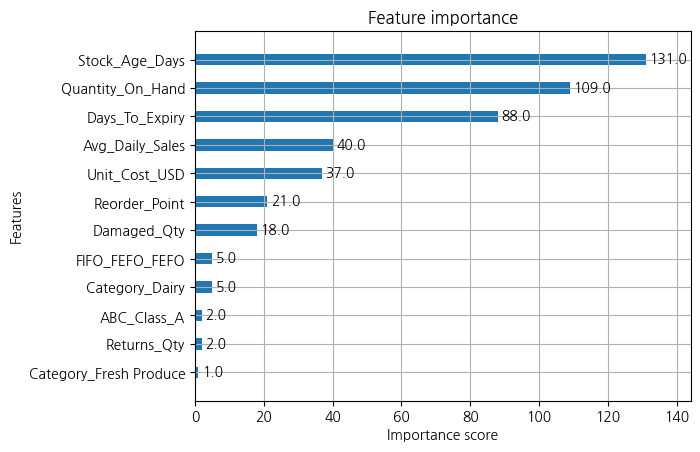

In [ ]:
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
# 분할기 고정
kf = KFold(shuffle=True,random_state=42)

scores = cross_validate(xgb,X_scaled,y_train,return_train_score=True,n_jobs=-1,cv=kf)
print('트레이닝 세트 정확도:',np.mean(scores['train_score']))
print('검증 세트 정확도: ', np.mean(scores['test_score']))
gbm_score = np.mean(scores['test_score'])
xgb.fit(X_scaled,y_train)
from xgboost import plot_importance
plot_importance(xgb,max_num_features=20,height=0.4)